In [1]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 1 - Install Required Libraries
# ==========================================================

!pip -q install mediapipe opencv-python pandas numpy tqdm

import os
import cv2
import json
import time
import shutil
import urllib.request
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 6.9 MB/s eta 0:00:00


In [15]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 2 - Google Drive + Face Landmarker + Project Paths
# ==========================================================

# ----------------------------------------------------------
# Gerekli ek kütüphaneler
# ----------------------------------------------------------

from google.colab import drive
from pathlib import Path
import urllib.request


# ==========================================================
# 1. GOOGLE DRIVE BAĞLANTISI
# ==========================================================

print("=" * 60)
print("Google Drive bağlanıyor...")
print("=" * 60)

# Google Drive'ı Colab ortamına bağlar.
# Drive zaten bağlıysa yeniden bağlamaya çalışmaz.
drive.mount(
    "/content/drive",
    force_remount=False
)

print("✓ Google Drive bağlantısı hazır.")


# ==========================================================
# 2. MEDIAPIPE FACE LANDMARKER MODELİ
# ==========================================================

# Face Landmarker modelinin Colab içerisindeki konumu.
#
# Bu dosyanın Drive'da tutulmasına gerek yoktur.
# Her yeni Colab oturumunda gerekirse tekrar indirilebilir.

MODEL_PATH = Path(
    "/content/face_landmarker.task"
)


# MediaPipe'ın Face Landmarker model dosyasının adresi.
MODEL_URL = (
    "https://storage.googleapis.com/"
    "mediapipe-models/"
    "face_landmarker/"
    "face_landmarker/"
    "float16/"
    "latest/"
    "face_landmarker.task"
)


# Model daha önce indirilmemişse indir.
if not MODEL_PATH.exists():

    print("\nFace Landmarker modeli indiriliyor...")

    urllib.request.urlretrieve(
        MODEL_URL,
        str(MODEL_PATH)
    )

    print("✓ Face Landmarker modeli indirildi.")

else:

    print("\n✓ Face Landmarker modeli zaten mevcut.")


# ==========================================================
# 3. INPUT ROOT
# ==========================================================

# INPUT_ROOT:
#
# Arkadaşımız tarafından hazırlanmış olan
# ham/ortak frame veri setinin bulunduğu klasördür.
#
# Buradaki görüntüler DEĞİŞTİRİLMEYECEKTİR.
# Kod yalnızca bu klasörden görüntü okuyacaktır.

INPUT_ROOT = Path(
    "/content/drive/MyDrive/"
    "AISC Çalışmalar/"
    "Deneyler/"
    "Deney 1 Frame"
)


# ==========================================================
# 4. PROJECT ROOT
# ==========================================================

# PROJECT_ROOT:
#
# Dilara'nın ağız bölgesi çalışmalarının bulunduğu
# ana klasördür.
#
# Mouth ROI çıktılarımız bunun altında oluşturulacaktır.

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "AISC Çalışmalar/"
    "Deneyler/"
    "Dilara/"
    "Deney 1/"
    "Ağız"
)


# ==========================================================
# 5. OUTPUT ROOT
# ==========================================================

# Kırpılmış ağız görüntülerinin, landmarkların,
# debug görüntülerinin ve metadata dosyalarının
# tamamı bu klasör altında tutulacaktır.

OUTPUT_ROOT = PROJECT_ROOT / "mouth_roi_output"


# ==========================================================
# 6. YOL KONTROLLERİ
# ==========================================================

print("\n")
print("=" * 60)
print("PROJE YOLLARI")
print("=" * 60)

print("\nINPUT_ROOT:")
print(INPUT_ROOT)

print("\nPROJECT_ROOT:")
print(PROJECT_ROOT)

print("\nOUTPUT_ROOT:")
print(OUTPUT_ROOT)

print("\nMODEL_PATH:")
print(MODEL_PATH)


# ==========================================================
# 7. DOSYA / KLASÖR VARLIK KONTROLÜ
# ==========================================================

print("\n")
print("=" * 60)
print("YOL KONTROLÜ")
print("=" * 60)

print(
    "INPUT_ROOT mevcut mu?   :",
    INPUT_ROOT.exists()
)

print(
    "PROJECT_ROOT mevcut mu? :",
    PROJECT_ROOT.exists()
)

print(
    "MODEL mevcut mu?        :",
    MODEL_PATH.exists()
)


# ==========================================================
# 8. KRİTİK KLASÖRLERİ DOĞRULA
# ==========================================================

# INPUT_ROOT bulunamazsa işlemi durdur.
# Çünkü frame'leri okuyamazsak ROI çıkaramayız.

if not INPUT_ROOT.exists():

    raise FileNotFoundError(
        "\nINPUT_ROOT bulunamadı.\n"
        "Deney 1 Frame klasörünün yolunu kontrol et."
    )


# PROJECT_ROOT bulunamazsa işlemi durdur.
# Çünkü çıktıları kaydedeceğimiz Ağız klasörü bulunamıyor
# demektir.

if not PROJECT_ROOT.exists():

    raise FileNotFoundError(
        "\nPROJECT_ROOT bulunamadı.\n"
        "Ağız klasörünün yolunu kontrol et."
    )


# Model bulunamazsa işlemi durdur.

if not MODEL_PATH.exists():

    raise FileNotFoundError(
        "\nFace Landmarker modeli bulunamadı."
    )


# ==========================================================
# 9. BAŞARILI
# ==========================================================

print("\n" + "=" * 60)
print("✓ CELL 2 BAŞARIYLA TAMAMLANDI")
print("=" * 60)

Google Drive bağlanıyor...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive bağlantısı hazır.

✓ Face Landmarker modeli zaten mevcut.


PROJE YOLLARI

INPUT_ROOT:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Deney 1 Frame

PROJECT_ROOT:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız

OUTPUT_ROOT:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output

MODEL_PATH:
/content/face_landmarker.task


YOL KONTROLÜ
INPUT_ROOT mevcut mu?   : True
PROJECT_ROOT mevcut mu? : True
MODEL mevcut mu?        : True

✓ CELL 2 BAŞARIYLA TAMAMLANDI


In [16]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 3 - Create Output Structure and Base Files
# ==========================================================

# Bu hücre:
#
# 1) mouth_roi_output ana klasörünü oluşturur.
# 2) fake / real sınıflarını oluşturur.
# 3) Her sınıf altında train / val / test oluşturur.
# 4) Her split altında:
#       - mouth
#       - debug
#       - landmarks
#    klasörlerini oluşturur.
# 5) Her split için metadata.csv oluşturur.
# 6) Her split için statistics.json oluşturur.
# 7) Proje kökünde genel metadata.csv oluşturur.
#
# NOT:
# Bu hücre henüz hiçbir frame'i işlemez.
# Sadece proje iskeletini hazırlar.


print("=" * 70)
print("MOUTH ROI OUTPUT YAPISI HAZIRLANIYOR")
print("=" * 70)


# ==========================================================
# 1. TEMEL SABİTLER
# ==========================================================

# İki sınıfımız var:
# fake -> deepfake görüntüler
# real -> gerçek görüntüler

LABELS = ["fake", "real"]


# Veri setinin mevcut bölünmesini kesinlikle değiştirmiyoruz.
# Ortak frame veri setindeki train / val / test yapısını koruyoruz.

SPLITS = ["train", "val", "test"]


# Her split altında oluşturulacak ağız projesine özel klasörler.

SUBFOLDERS = [
    "mouth",       # Model eğitiminde kullanılacak kırpılmış ağız görüntüleri
    "debug",       # Bounding box / landmark kontrol görüntüleri
    "landmarks"    # MediaPipe landmark koordinat kayıtları
]


# ==========================================================
# 2. ANA OUTPUT KLASÖRÜNÜ OLUŞTUR
# ==========================================================

# OUTPUT_ROOT daha önce Cell 2'de:
#
# .../Ağız/mouth_roi_output
#
# şeklinde tanımlandı.
#
# exist_ok=True:
# Klasör zaten varsa hata vermez.
#
# parents=True:
# Gereken üst klasörleri de oluşturabilir.

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print(f"\n✓ Ana çıktı klasörü hazır:")
print(OUTPUT_ROOT)


# ==========================================================
# 3. FAKE / REAL + TRAIN / VAL / TEST YAPISI
# ==========================================================

for label in LABELS:

    for split in SPLITS:

        # Örnek:
        #
        # mouth_roi_output/fake/train
        # mouth_roi_output/real/test

        split_root = OUTPUT_ROOT / label / split

        split_root.mkdir(
            parents=True,
            exist_ok=True
        )

        # --------------------------------------------------
        # mouth / debug / landmarks klasörleri
        # --------------------------------------------------

        for subfolder in SUBFOLDERS:

            folder_path = split_root / subfolder

            folder_path.mkdir(
                parents=True,
                exist_ok=True
            )


print("\n✓ fake / real klasörleri oluşturuldu.")
print("✓ train / val / test klasörleri oluşturuldu.")
print("✓ mouth / debug / landmarks klasörleri oluşturuldu.")


# ==========================================================
# 4. METADATA KOLONLARI
# ==========================================================

# Arkadaşının Eye ROI metadata yapısını temel alıyoruz.
#
# Ancak:
#
# left_eye_*
# right_eye_*
# combined_eye_*
#
# gibi göze özgü alanları kaldırıyoruz.
#
# Bunların yerine mouth_* alanları kullanıyoruz.


METADATA_COLUMNS = [

    # ------------------------------------------------------
    # ÖRNEK KİMLİĞİ
    # ------------------------------------------------------

    "sample_id",

    # Orijinal frame'in tam yolu
    "source_frame",

    # INPUT_ROOT'a göre göreli yol
    "relative_frame_path",

    # real / fake
    "label",

    # train / val / test
    "split",

    # Frame'in geldiği video kimliği
    "video_id",

    # Dosyanın uzantısız adı
    "frame_stem",

    # ------------------------------------------------------
    # YÜZ BİLGİLERİ
    # ------------------------------------------------------

    # Bir frame içerisinde birden fazla yüz olması ihtimaline karşı
    "face_id",

    # face_id'nin hangi kapsamda oluşturulduğunu belirtmek için
    "face_id_scope",

    # Frame içinde kaç yüz bulundu
    "faces_in_frame",

    # ------------------------------------------------------
    # MOUTH ROI BİLGİLERİ
    # ------------------------------------------------------

    # Ağız ROI başarıyla çıkarıldı mı?
    "mouth_detected",

    # Kırpılmış ağız görüntüsünün yolu
    "mouth_path",

    # Debug görüntüsünün yolu
    "debug_path",

    # Landmark JSON dosyasının yolu
    "landmarks_path",

    # ------------------------------------------------------
    # MOUTH BOUNDING BOX
    # ------------------------------------------------------

    "mouth_bbox_x1",
    "mouth_bbox_y1",
    "mouth_bbox_x2",
    "mouth_bbox_y2",

    # Crop'un orijinal piksel boyutları
    "mouth_width_px",
    "mouth_height_px",

    # ------------------------------------------------------
    # LANDMARK BİLGİSİ
    # ------------------------------------------------------

    "landmark_count",

    # ------------------------------------------------------
    # İŞLEM DURUMU
    # ------------------------------------------------------

    # SUCCESS / SKIPPED / ERROR
    "status",

    # Hata varsa açıklaması
    "error",

    # Bir frame'in işlenme süresi
    "processing_ms"
]


# ==========================================================
# 5. HER SPLIT İÇİN metadata.csv OLUŞTUR
# ==========================================================

for label in LABELS:

    for split in SPLITS:

        split_root = OUTPUT_ROOT / label / split

        split_metadata_path = (
            split_root / "metadata.csv"
        )

        # Dosya daha önce oluşturulmadıysa oluştur.
        # Böylece notebook tekrar çalıştırıldığında mevcut
        # metadata yanlışlıkla silinmez.

        if not split_metadata_path.exists():

            empty_metadata = pd.DataFrame(
                columns=METADATA_COLUMNS
            )

            empty_metadata.to_csv(
                split_metadata_path,
                index=False,
                encoding="utf-8-sig"
            )


print("✓ Her split için metadata.csv hazır.")


# ==========================================================
# 6. HER SPLIT İÇİN statistics.json OLUŞTUR
# ==========================================================

# Başlangıçta bütün sayaçlar 0 olacak.
# Frame işleme sırasında bu değerleri güncelleyeceğiz.

for label in LABELS:

    for split in SPLITS:

        split_root = OUTPUT_ROOT / label / split

        statistics_path = (
            split_root / "statistics.json"
        )

        if not statistics_path.exists():

            initial_statistics = {

                "label": label,
                "split": split,

                # Toplam kaç frame işlendi?
                "total_inputs": 0,

                # Başarılı Mouth ROI
                "success_count": 0,

                # Bilinçli olarak atlanan frame
                "skipped_count": 0,

                # Teknik hata oluşan frame
                "error_count": 0,

                # Hiç yüz bulunamayan frame
                "no_face_count": 0,

                # Yüz bulundu fakat ağız ROI üretilemedi
                "mouth_not_detected_count": 0,

                # Ortalama işlem süresi
                "average_processing_ms": 0.0
            }

            with open(
                statistics_path,
                "w",
                encoding="utf-8"
            ) as file:

                json.dump(
                    initial_statistics,
                    file,
                    ensure_ascii=False,
                    indent=4
                )


print("✓ Her split için statistics.json hazır.")


# ==========================================================
# 7. GENEL metadata.csv
# ==========================================================

# Eye ROI projesinde olduğu gibi mouth_roi_output kökünde
# bütün splitleri bir arada tutacak genel metadata da olacak.

GLOBAL_METADATA_PATH = (
    OUTPUT_ROOT / "metadata.csv"
)

if not GLOBAL_METADATA_PATH.exists():

    pd.DataFrame(
        columns=METADATA_COLUMNS
    ).to_csv(
        GLOBAL_METADATA_PATH,
        index=False,
        encoding="utf-8-sig"
    )


print("✓ Genel metadata.csv hazır.")


# ==========================================================
# 8. SON KONTROL
# ==========================================================

print("\n" + "=" * 70)
print("OLUŞTURULAN YAPI")
print("=" * 70)

for label in LABELS:

    print(f"\n[{label.upper()}]")

    for split in SPLITS:

        split_root = OUTPUT_ROOT / label / split

        print(
            f"  {split:<5} -> "
            f"{split_root.exists()}"
        )

        for subfolder in SUBFOLDERS:

            folder = split_root / subfolder

            print(
                f"      {subfolder:<10} -> "
                f"{folder.exists()}"
            )


print("\n" + "=" * 70)
print("✓ CELL 3 BAŞARIYLA TAMAMLANDI")
print("=" * 70)

MOUTH ROI OUTPUT YAPISI HAZIRLANIYOR

✓ Ana çıktı klasörü hazır:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output

✓ fake / real klasörleri oluşturuldu.
✓ train / val / test klasörleri oluşturuldu.
✓ mouth / debug / landmarks klasörleri oluşturuldu.
✓ Her split için metadata.csv hazır.
✓ Her split için statistics.json hazır.
✓ Genel metadata.csv hazır.

OLUŞTURULAN YAPI

[FAKE]
  train -> True
      mouth      -> True
      debug      -> True
      landmarks  -> True
  val   -> True
      mouth      -> True
      debug      -> True
      landmarks  -> True
  test  -> True
      mouth      -> True
      debug      -> True
      landmarks  -> True

[REAL]
  train -> True
      mouth      -> True
      debug      -> True
      landmarks  -> True
  val   -> True
      mouth      -> True
      debug      -> True
      landmarks  -> True
  test  -> True
      mouth      -> True
      debug      -> True
      landmarks  -> True

✓ CELL 3 BAŞARIYLA TAMAML

In [17]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 4 - Face Landmarker Configuration + Mouth Landmarks
# ==========================================================

# Bu hücrede:
#
# 1) MediaPipe Face Landmarker için temel çalışma ayarları belirlenir.
# 2) Ağız bölgesine ait landmark indeksleri tanımlanır.
# 3) Mouth ROI için padding ve çıktı boyutu belirlenir.
# 4) FaceLandmarker nesnesi oluşturulur.
#
# Henüz hiçbir görüntü işlenmez.
# Gerçek frame testi bir sonraki hücrede yapılacaktır.


print("=" * 70)
print("FACE LANDMARKER VE MOUTH LANDMARK AYARLARI")
print("=" * 70)


# ==========================================================
# 1. FACE LANDMARKER AYARLARI
# ==========================================================

# Bir frame içerisinde bulunabilecek maksimum yüz sayısı.
#
# Arkadaşımızın Eye ROI notebook'unda da 10 kullanılmış.
# Böylece kalabalık frame'lerde yalnızca ilk yüzü almak yerine
# bütün yüzleri işleyebilme imkanımız olur.

NUM_FACES = 10


# ----------------------------------------------------------
# Minimum yüz tespit güven skoru
# ----------------------------------------------------------
#
# MediaPipe bir bölgenin yüz olduğuna en az bu kadar
# güveniyorsa yüz olarak kabul edilir.
#
# Eye ROI notebook'u ile aynı başlangıç değeri kullanılıyor.

DET_CONF = 0.30


# ----------------------------------------------------------
# Minimum face presence confidence
# ----------------------------------------------------------
#
# Tespit edilen yüzün gerçekten görüntü içerisinde
# mevcut olduğuna ilişkin minimum güven değeridir.

PRESENCE_CONF = 0.30


# ----------------------------------------------------------
# Minimum tracking confidence
# ----------------------------------------------------------
#
# Face Landmarker'ın yüz takibi için kullandığı
# minimum güven değeridir.
#
# Biz görüntüleri bağımsız frame olarak işleyeceğiz;
# yine de model yapılandırmasının bir parçası olarak tutulur.

TRACKING_CONF = 0.30


# ==========================================================
# 2. MOUTH ROI AYARLARI
# ==========================================================

# Ağız bounding box'ının çevresine eklenecek boşluk.
#
# 0.25 = ağız kutusunun genişlik/yüksekliğinin yaklaşık
# %25'i oranında çevresel padding uygulanması demektir.
#
# Bunu başlangıç değeri olarak kullanacağız.
# Debug çıktıları incelendikten sonra gerekirse
# 0.20 / 0.30 gibi değerlerle tekrar değerlendirilebilir.

MOUTH_PADDING_RATIO = 0.25


# Model eğitiminde kullanılacak nihai görüntü boyutu.
#
# Arkadaşımızın göz çalışmasında da 224 kullanılmıştır.
# Ekip standardını korumak için ağız tarafında da
# başlangıçta 224 x 224 kullanacağız.

OUTPUT_SIZE = 224


# ==========================================================
# 3. KAYIT AYARLARI
# ==========================================================

# Debug görüntülerini kaydet.
#
# Debug görüntüsünde daha sonra:
# - ağız landmarkları
# - bounding box
# - face_id
#
# gibi bilgileri göstereceğiz.

SAVE_DEBUG = True


# Kaç işlenmiş kayıt sonrası metadata'nın diske
# zorunlu olarak yazılacağını belirler.
#
# Colab oturumu kesilirse veri kaybını azaltmak için kullanılır.

FLUSH_EVERY = 25


# False olduğunda daha önce oluşturulmuş ROI dosyalarının
# üzerine yazılmaz.
#
# Bu, yanlışlıkla mevcut çıktıları silmemek için
# daha güvenli başlangıç davranışıdır.

OVERWRITE = False


# ==========================================================
# 4. AĞIZ LANDMARK İNDEKSLERİ
# ==========================================================

# MediaPipe Face Mesh / Face Landmarker yüz ağı üzerinde
# dudakların dış ve iç konturlarını temsil eden landmarklar.
#
# Hem üst-alt dudak sınırlarını hem de ağız köşelerini
# kapsayacak şekilde seçilmiştir.
#
# Bounding box hesaplanırken bu landmarkların minimum ve
# maksimum x-y koordinatları kullanılacaktır.

MOUTH_LANDMARKS = sorted({
    # ------------------------------------------------------
    # DIŞ DUDAK KONTURU
    # ------------------------------------------------------
    61, 146, 91, 181, 84, 17,
    314, 405, 321, 375, 291,

    185, 40, 39, 37, 0,
    267, 269, 270, 409,

    # ------------------------------------------------------
    # İÇ DUDAK KONTURU
    # ------------------------------------------------------
    78, 95, 88, 178, 87, 14,
    317, 402, 318, 324, 308,

    191, 80, 81, 82, 13,
    312, 311, 310, 415
})


# Landmark sayısını kontrol amaçlı yazdırıyoruz.
MOUTH_LANDMARK_COUNT = len(MOUTH_LANDMARKS)


print(f"\nAğız landmark sayısı: {MOUTH_LANDMARK_COUNT}")
print("Ağız landmark indeksleri:")
print(MOUTH_LANDMARKS)


# ==========================================================
# 5. MEDIAPIPE FACE LANDMARKER OLUŞTUR
# ==========================================================

# BaseOptions:
# Kullanılacak .task model dosyasını MediaPipe'a bildirir.

base_options = python.BaseOptions(
    model_asset_path=str(MODEL_PATH)
)


# ----------------------------------------------------------
# FaceLandmarkerOptions
# ----------------------------------------------------------
#
# running_mode = IMAGE
#
# Çünkü elimizde video akışı değil,
# önceden çıkarılmış bağımsız frame görüntüleri var.
#
# output_face_blendshapes:
# Şimdilik blendshape skorlarına ihtiyacımız olmadığı için False.
#
# output_facial_transformation_matrixes:
# Bu aşamada yalnızca ROI çıkardığımız için False.

landmarker_options = vision.FaceLandmarkerOptions(

    base_options=base_options,

    running_mode=vision.RunningMode.IMAGE,

    num_faces=NUM_FACES,

    min_face_detection_confidence=DET_CONF,

    min_face_presence_confidence=PRESENCE_CONF,

    min_tracking_confidence=TRACKING_CONF,

    output_face_blendshapes=False,

    output_facial_transformation_matrixes=False
)


# ----------------------------------------------------------
# Face Landmarker nesnesini oluştur
# ----------------------------------------------------------

face_landmarker = vision.FaceLandmarker.create_from_options(
    landmarker_options
)


# ==========================================================
# 6. AYARLARI EKRANA YAZDIR
# ==========================================================

print("\n" + "=" * 70)
print("MOUTH ROI AYARLARI")
print("=" * 70)

print(f"NUM_FACES           : {NUM_FACES}")
print(f"Detection confidence: {DET_CONF}")
print(f"Presence confidence : {PRESENCE_CONF}")
print(f"Tracking confidence : {TRACKING_CONF}")

print(f"Mouth padding       : {MOUTH_PADDING_RATIO}")
print(f"Output size         : {OUTPUT_SIZE} x {OUTPUT_SIZE}")

print(f"Save debug          : {SAVE_DEBUG}")
print(f"Flush every         : {FLUSH_EVERY}")
print(f"Overwrite           : {OVERWRITE}")

print(f"Mouth landmarks     : {MOUTH_LANDMARK_COUNT}")


print("\n" + "=" * 70)
print("✓ CELL 4 BAŞARIYLA TAMAMLANDI")
print("=" * 70)

FACE LANDMARKER VE MOUTH LANDMARK AYARLARI

Ağız landmark sayısı: 40
Ağız landmark indeksleri:
[0, 13, 14, 17, 37, 39, 40, 61, 78, 80, 81, 82, 84, 87, 88, 91, 95, 146, 178, 181, 185, 191, 267, 269, 270, 291, 308, 310, 311, 312, 314, 317, 318, 321, 324, 375, 402, 405, 409, 415]

MOUTH ROI AYARLARI
NUM_FACES           : 10
Detection confidence: 0.3
Presence confidence : 0.3
Tracking confidence : 0.3
Mouth padding       : 0.25
Output size         : 224 x 224
Save debug          : True
Flush every         : 25
Overwrite           : False
Mouth landmarks     : 40

✓ CELL 4 BAŞARIYLA TAMAMLANDI


TEK FRAME ÜZERİNDE MOUTH ROI TESTİ

✓ Test frame bulundu:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Deney 1 Frame/Fake/train/fake_train_01130.jpg

Frame boyutu:
Genişlik : 1920px
Yükseklik: 1080px

Tespit edilen yüz sayısı:
1
✓ En az bir yüz başarıyla bulundu.

Kullanılan ağız landmark sayısı: 40

Padding öncesi Mouth Bounding Box:
x1=1297, y1=385, x2=1386, y2=445
Boyut: 89 x 60px

Padding sonrası Mouth Bounding Box:
x1=1275, y1=370, x2=1408, y2=460

Crop boyutu:
133 x 90px


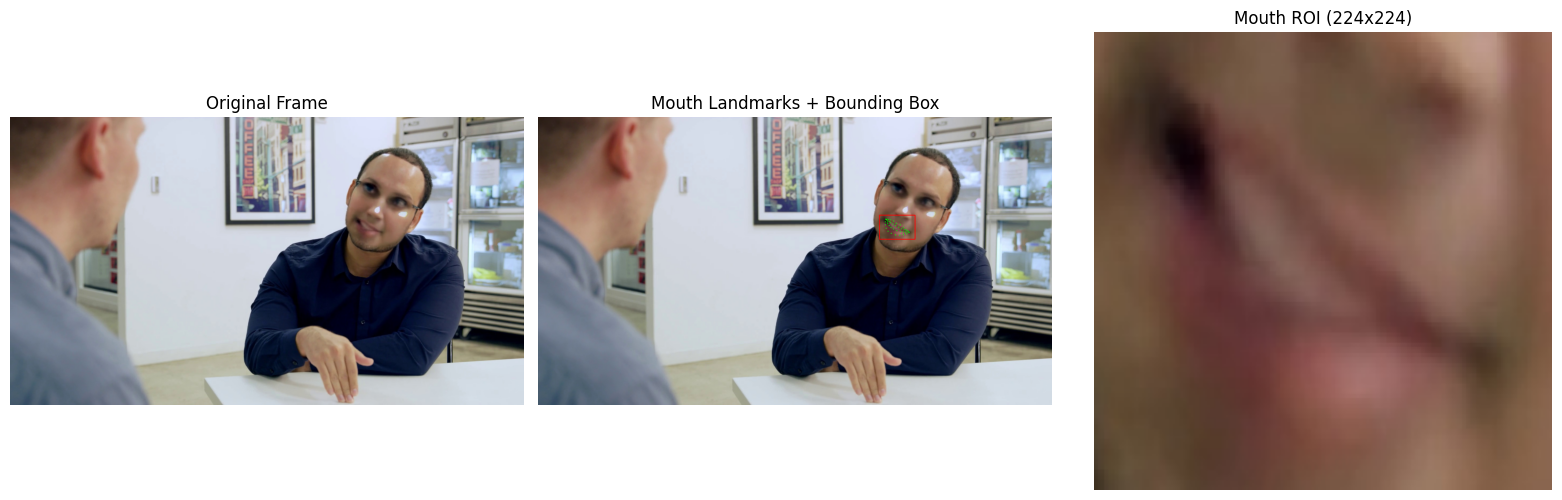


TEST SONUCU
Frame           : fake_train_01130.jpg
Tespit edilen yüz: 1
Mouth landmarks : 40
Orijinal crop   : 133 x 90
Model input     : 224 x 224
Padding ratio   : 0.25

✓ CELL 5 BAŞARIYLA TAMAMLANDI


In [18]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 5 - Single Frame Mouth ROI Test
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Veri setinden otomatik olarak bir örnek frame bulmak.
# 2) Frame'i OpenCV ile okumak.
# 3) MediaPipe Face Landmarker ile yüz landmarklarını çıkarmak.
# 4) Ağız landmarklarından bounding box hesaplamak.
# 5) Ağız çevresine padding eklemek.
# 6) Ağız bölgesini crop etmek.
# 7) ROI'yi 224x224 boyutuna getirmek.
# 8) Sonucu ekranda görsel olarak kontrol etmek.
#
# ÖNEMLİ:
# Bu hücre henüz Drive'a kalıcı ROI kaydetmez.
# Önce crop kalitesini kontrol edeceğiz.


# ==========================================================
# 1. GÖRSELLEŞTİRME KÜTÜPHANESİ
# ==========================================================

import matplotlib.pyplot as plt


print("=" * 70)
print("TEK FRAME ÜZERİNDE MOUTH ROI TESTİ")
print("=" * 70)


# ==========================================================
# 2. DESTEKLENEN GÖRÜNTÜ FORMATLARI
# ==========================================================

# Veri setindeki olası görüntü uzantıları.
# Büyük/küçük harf problemi yaşamamak için suffix.lower()
# kullanacağız.

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


# ==========================================================
# 3. TEST FRAME'İ BUL
# ==========================================================

# Öncelikle Fake/train içerisinden bir görüntü bulmaya çalışıyoruz.
#
# Eğer orada görüntü bulunamazsa Real/train denenir.
#
# rglob("*") kullanmamızın nedeni:
# Frame'ler doğrudan train klasöründe olmayabilir;
# video bazlı alt klasörler içerisinde de bulunabilir.


candidate_folders = [
    INPUT_ROOT / "Fake" / "train",
    INPUT_ROOT / "Real" / "train"
]


TEST_FRAME_PATH = None


for folder in candidate_folders:

    # Klasör gerçekten mevcut mu?
    if not folder.exists():
        continue

    # Alt klasörler dahil bütün dosyaları tara.
    for file_path in folder.rglob("*"):

        if (
            file_path.is_file()
            and file_path.suffix.lower() in IMAGE_EXTENSIONS
        ):

            TEST_FRAME_PATH = file_path
            break

    # Bir görüntü bulunduysa diğer klasörleri arama.
    if TEST_FRAME_PATH is not None:
        break


# Eğer hiçbir görüntü bulunamadıysa işlemi durdur.
if TEST_FRAME_PATH is None:

    raise FileNotFoundError(
        "Test için kullanılabilecek hiçbir frame bulunamadı. "
        "Fake/Real train klasörlerini kontrol edin."
    )


print("\n✓ Test frame bulundu:")
print(TEST_FRAME_PATH)


# ==========================================================
# 4. FRAME'İ OPENCV İLE OKU
# ==========================================================

# OpenCV görüntüyü BGR renk düzeninde okur.

frame_bgr = cv2.imread(
    str(TEST_FRAME_PATH)
)


# Görüntü okunamadıysa devam etmiyoruz.
if frame_bgr is None:

    raise RuntimeError(
        f"Görüntü OpenCV tarafından okunamadı:\n"
        f"{TEST_FRAME_PATH}"
    )


# Görüntünün orijinal boyutlarını al.
frame_height, frame_width = frame_bgr.shape[:2]


print("\nFrame boyutu:")
print(f"Genişlik : {frame_width}px")
print(f"Yükseklik: {frame_height}px")


# ==========================================================
# 5. BGR -> RGB DÖNÜŞÜMÜ
# ==========================================================

# MediaPipe RGB formatıyla çalışır.
#
# OpenCV ise görüntüyü BGR olarak okuduğu için
# renk uzayını dönüştürüyoruz.

frame_rgb = cv2.cvtColor(
    frame_bgr,
    cv2.COLOR_BGR2RGB
)


# NumPy dizisinin bellekte ardışık olmasını sağlıyoruz.
# MediaPipe açısından daha güvenli bir giriş oluşturur.

frame_rgb = np.ascontiguousarray(
    frame_rgb
)


# ==========================================================
# 6. NUMPY -> MEDIAPIPE IMAGE
# ==========================================================

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=frame_rgb
)


# ==========================================================
# 7. FACE LANDMARKER ÇALIŞTIR
# ==========================================================

# Cell 4'te oluşturduğumuz face_landmarker nesnesini
# bu frame üzerinde çalıştırıyoruz.

detection_result = face_landmarker.detect(
    mp_image
)


# ==========================================================
# 8. YÜZ BULUNDU MU?
# ==========================================================

face_landmarks_list = (
    detection_result.face_landmarks
)


faces_found = len(
    face_landmarks_list
)


print("\nTespit edilen yüz sayısı:")
print(faces_found)


if faces_found == 0:

    raise RuntimeError(
        "Bu test frame'inde MediaPipe tarafından yüz bulunamadı."
    )


print("✓ En az bir yüz başarıyla bulundu.")


# ==========================================================
# 9. TEST İÇİN İLK YÜZÜ SEÇ
# ==========================================================

# Şimdilik yalnızca test amacıyla ilk tespit edilen yüzü
# kullanıyoruz.
#
# Daha sonra tüm dataset işlenirken her yüz için
# face_id oluşturacağız ve gerektiğinde birden fazla yüzü
# ayrı ayrı kaydedeceğiz.

face_landmarks = face_landmarks_list[0]


# ==========================================================
# 10. MOUTH LANDMARK KOORDİNATLARINI PİKSELE ÇEVİR
# ==========================================================

# MediaPipe landmark koordinatları normalize biçimdedir:
#
# x -> 0 ile 1
# y -> 0 ile 1
#
# Bunları görüntünün gerçek piksel koordinatlarına
# dönüştürüyoruz.

mouth_points = []


for landmark_index in MOUTH_LANDMARKS:

    landmark = face_landmarks[
        landmark_index
    ]

    # Normalize x -> piksel x
    x = int(
        landmark.x * frame_width
    )

    # Normalize y -> piksel y
    y = int(
        landmark.y * frame_height
    )

    mouth_points.append(
        (x, y)
    )


# Listeyi NumPy dizisine çevir.
mouth_points = np.array(
    mouth_points,
    dtype=np.int32
)


print(
    f"\nKullanılan ağız landmark sayısı: "
    f"{len(mouth_points)}"
)


# ==========================================================
# 11. HAM AĞIZ BOUNDING BOX
# ==========================================================

# Ağız landmarklarının:
#
# minimum x
# minimum y
# maksimum x
# maksimum y
#
# değerlerini kullanarak ağız çevresinde dikdörtgen
# bounding box oluşturuyoruz.


mouth_x1 = int(
    np.min(mouth_points[:, 0])
)

mouth_y1 = int(
    np.min(mouth_points[:, 1])
)

mouth_x2 = int(
    np.max(mouth_points[:, 0])
)

mouth_y2 = int(
    np.max(mouth_points[:, 1])
)


# Ham ağız genişliği ve yüksekliği.
mouth_width = (
    mouth_x2 - mouth_x1
)

mouth_height = (
    mouth_y2 - mouth_y1
)


if mouth_width <= 0 or mouth_height <= 0:

    raise RuntimeError(
        "Geçersiz Mouth Bounding Box hesaplandı."
    )


print("\nPadding öncesi Mouth Bounding Box:")
print(
    f"x1={mouth_x1}, "
    f"y1={mouth_y1}, "
    f"x2={mouth_x2}, "
    f"y2={mouth_y2}"
)

print(
    f"Boyut: "
    f"{mouth_width} x {mouth_height}px"
)


# ==========================================================
# 12. PADDING HESAPLA
# ==========================================================

# Ağız yalnızca dudak çizgisinden kesilirse
# model çevresel manipülasyon izlerini kaçırabilir.
#
# Bu yüzden ağız çevresine belirli miktarda boşluk
# ekliyoruz.
#
# Cell 4'te:
#
# MOUTH_PADDING_RATIO = 0.25
#
# olarak belirlemiştik.


padding_x = int(
    mouth_width * MOUTH_PADDING_RATIO
)

padding_y = int(
    mouth_height * MOUTH_PADDING_RATIO
)


# Bounding box'ı genişlet.
crop_x1 = mouth_x1 - padding_x
crop_y1 = mouth_y1 - padding_y

crop_x2 = mouth_x2 + padding_x
crop_y2 = mouth_y2 + padding_y


# ==========================================================
# 13. BOUNDING BOX'I GÖRÜNTÜ SINIRLARINDA TUT
# ==========================================================

# Padding yüzünden koordinatlar görüntü dışına çıkabilir.
#
# Örneğin:
# x1 = -15
#
# gibi bir değer oluşmasını engelliyoruz.


crop_x1 = max(
    0,
    crop_x1
)

crop_y1 = max(
    0,
    crop_y1
)

crop_x2 = min(
    frame_width,
    crop_x2
)

crop_y2 = min(
    frame_height,
    crop_y2
)


print("\nPadding sonrası Mouth Bounding Box:")
print(
    f"x1={crop_x1}, "
    f"y1={crop_y1}, "
    f"x2={crop_x2}, "
    f"y2={crop_y2}"
)


# ==========================================================
# 14. MOUTH ROI CROP
# ==========================================================

mouth_crop_bgr = frame_bgr[
    crop_y1:crop_y2,
    crop_x1:crop_x2
]


# Crop boş mu?
if mouth_crop_bgr.size == 0:

    raise RuntimeError(
        "Mouth ROI boş çıktı."
    )


original_crop_height, original_crop_width = (
    mouth_crop_bgr.shape[:2]
)


print("\nCrop boyutu:")
print(
    f"{original_crop_width} x "
    f"{original_crop_height}px"
)


# ==========================================================
# 15. ROI'Yİ 224 x 224 BOYUTUNA GETİR
# ==========================================================

# Cell 4'te OUTPUT_SIZE = 224 belirlemiştik.
#
# Böylece sonraki CNN modellerine sabit boyutlu
# görüntüler verebiliriz.


mouth_crop_resized_bgr = cv2.resize(
    mouth_crop_bgr,
    (OUTPUT_SIZE, OUTPUT_SIZE),
    interpolation=cv2.INTER_AREA
)


# Matplotlib RGB beklediği için RGB'ye çevir.
mouth_crop_resized_rgb = cv2.cvtColor(
    mouth_crop_resized_bgr,
    cv2.COLOR_BGR2RGB
)


# ==========================================================
# 16. DEBUG GÖRÜNTÜSÜ HAZIRLA
# ==========================================================

# Orijinal frame'i değiştirmemek için kopya oluştur.

debug_bgr = frame_bgr.copy()


# ----------------------------------------------------------
# Ağız landmarklarını çiz
# ----------------------------------------------------------

for x, y in mouth_points:

    cv2.circle(
        debug_bgr,
        (int(x), int(y)),
        2,
        (0, 255, 0),
        -1
    )


# ----------------------------------------------------------
# Padding uygulanmış bounding box'ı çiz
# ----------------------------------------------------------

cv2.rectangle(
    debug_bgr,
    (crop_x1, crop_y1),
    (crop_x2, crop_y2),
    (0, 0, 255),
    2
)


# Debug görüntüsünü RGB'ye çevir.

debug_rgb = cv2.cvtColor(
    debug_bgr,
    cv2.COLOR_BGR2RGB
)


# ==========================================================
# 17. SONUÇLARI EKRANDA GÖSTER
# ==========================================================

# Üç farklı görüntü göstereceğiz:
#
# 1) Orijinal frame
# 2) Landmark + bounding box
# 3) Nihai Mouth ROI


original_rgb = cv2.cvtColor(
    frame_bgr,
    cv2.COLOR_BGR2RGB
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)


# ----------------------------------------------------------
# Orijinal frame
# ----------------------------------------------------------

axes[0].imshow(
    original_rgb
)

axes[0].set_title(
    "Original Frame"
)

axes[0].axis(
    "off"
)


# ----------------------------------------------------------
# Debug görüntüsü
# ----------------------------------------------------------

axes[1].imshow(
    debug_rgb
)

axes[1].set_title(
    "Mouth Landmarks + Bounding Box"
)

axes[1].axis(
    "off"
)


# ----------------------------------------------------------
# Nihai ağız ROI
# ----------------------------------------------------------

axes[2].imshow(
    mouth_crop_resized_rgb
)

axes[2].set_title(
    f"Mouth ROI ({OUTPUT_SIZE}x{OUTPUT_SIZE})"
)

axes[2].axis(
    "off"
)


plt.tight_layout()
plt.show()


# ==========================================================
# 18. TEST ÖZETİ
# ==========================================================

print("\n" + "=" * 70)
print("TEST SONUCU")
print("=" * 70)

print(
    f"Frame           : "
    f"{TEST_FRAME_PATH.name}"
)

print(
    f"Tespit edilen yüz: "
    f"{faces_found}"
)

print(
    f"Mouth landmarks : "
    f"{len(mouth_points)}"
)

print(
    f"Orijinal crop   : "
    f"{original_crop_width} x "
    f"{original_crop_height}"
)

print(
    f"Model input     : "
    f"{OUTPUT_SIZE} x {OUTPUT_SIZE}"
)

print(
    f"Padding ratio   : "
    f"{MOUTH_PADDING_RATIO}"
)

print("\n✓ CELL 5 BAŞARIYLA TAMAMLANDI")
print("=" * 70)

TEK FRAME ÜZERİNDE MOUTH ROI TESTİ

✓ Test frame bulundu:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Deney 1 Frame/Fake/train/fake_train_01130.jpg

Frame boyutu:
Genişlik : 1920px
Yükseklik: 1080px

Tespit edilen yüz sayısı:
1
✓ En az bir yüz başarıyla bulundu.

Kullanılan ağız landmark sayısı: 40

Padding öncesi Mouth Bounding Box:
x1=1297, y1=385, x2=1387, y2=446
Boyut: 90 x 61px

Padding sonrası Mouth Bounding Box:
x1=1275, y1=370, x2=1409, y2=461

Crop boyutu:
134 x 91px

Resize bilgileri:
Orijinal : 134 x 91
Resize   : 224 x 152
Scale    : 1.6716
Offset X : 0
Offset Y : 36


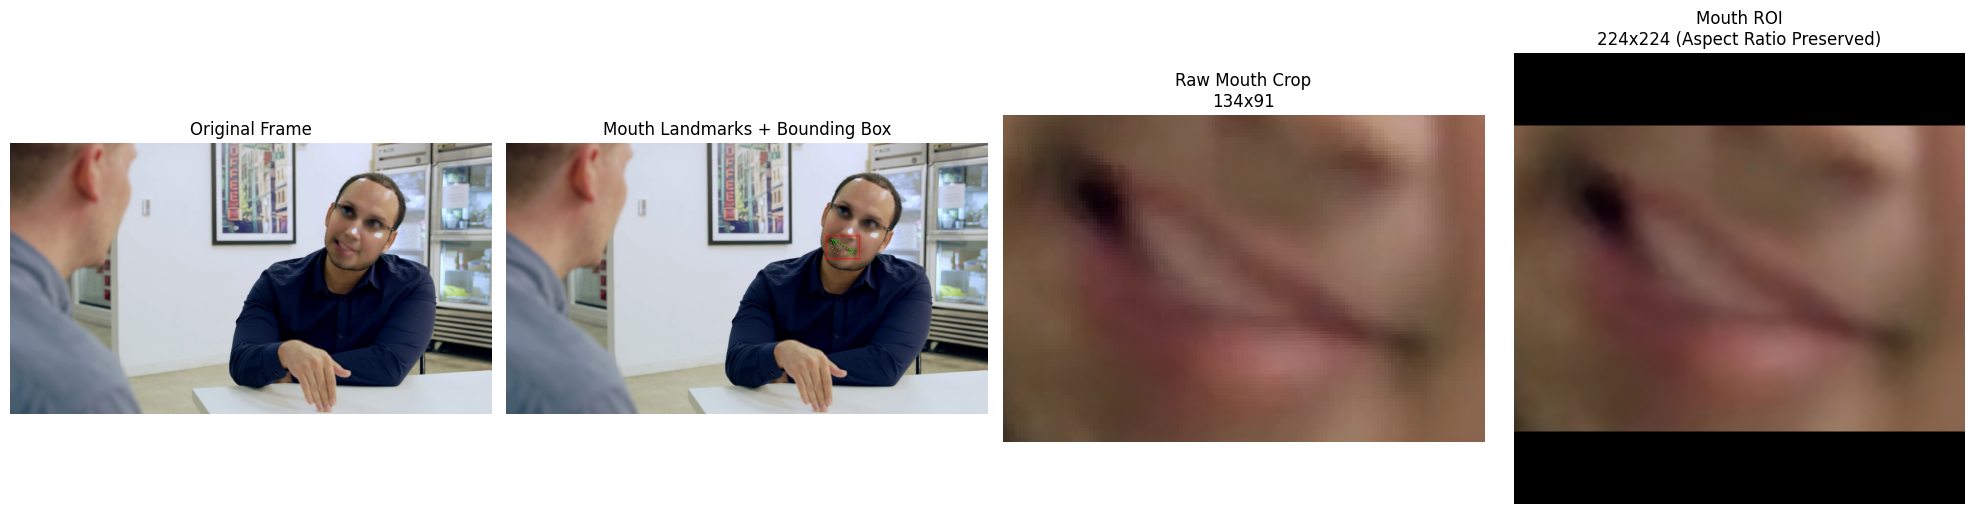


TEST SONUCU
Frame             : fake_train_01130.jpg
Tespit edilen yüz : 1
Mouth landmarks   : 40
Ham ağız bbox     : 90 x 61
Paddingli crop    : 134 x 91
Nihai model input : 224 x 224
Padding ratio     : 0.25
Resize scale      : 1.6716

✓ CELL 5 BAŞARIYLA TAMAMLANDI


In [19]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 5 - Single Frame Mouth ROI Test
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Veri setinden otomatik olarak bir örnek frame bulmak.
# 2) Frame'i OpenCV ile okumak.
# 3) MediaPipe Face Landmarker ile yüz landmarklarını çıkarmak.
# 4) Ağız landmarklarından bounding box hesaplamak.
# 5) Ağız çevresine padding eklemek.
# 6) Ağız bölgesini crop etmek.
# 7) En-boy oranını BOZMADAN 224x224 boyutuna hazırlamak.
# 8) Debug görüntüsü oluşturmak.
# 9) Sonucu görsel olarak kontrol etmek.
#
# ÖNEMLİ:
# Bu hücre henüz Drive'a toplu çıktı kaydetmez.
# Amaç önce Mouth ROI standardının doğru olduğunu kontrol etmektir.


# ==========================================================
# 1. GÖRSELLEŞTİRME
# ==========================================================

import matplotlib.pyplot as plt


print("=" * 70)
print("TEK FRAME ÜZERİNDE MOUTH ROI TESTİ")
print("=" * 70)


# ==========================================================
# 2. DESTEKLENEN GÖRÜNTÜ UZANTILARI
# ==========================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


# ==========================================================
# 3. EN-BOY ORANINI KORUYAN RESIZE FONKSİYONU
# ==========================================================

def resize_with_padding(image, output_size=224):
    """
    Görüntüyü en-boy oranını bozmadan kare forma getirir.

    İşlem sırası:
    1) Görüntünün mevcut genişlik ve yüksekliğini alır.
    2) Uzun kenarı output_size değerine sığdırır.
    3) Diğer kenarı aynı ölçek oranıyla küçültür/büyütür.
    4) Sonuç görüntüsünü kare bir tuvalin merkezine yerleştirir.
    5) Boş alanları siyah padding ile doldurur.

    Parametreler
    ------------
    image : np.ndarray
        OpenCV tarafından okunmuş BGR görüntüsü.

    output_size : int
        Nihai görüntünün genişliği ve yüksekliği.

    Döndürür
    --------
    padded_image : np.ndarray
        output_size x output_size boyutunda BGR görüntü.

    resize_info : dict
        Resize işlemine ait ek bilgiler.
    """

    # ------------------------------------------------------
    # Orijinal crop boyutunu al
    # ------------------------------------------------------

    height, width = image.shape[:2]

    if width <= 0 or height <= 0:
        raise ValueError(
            "resize_with_padding fonksiyonuna geçersiz görüntü verildi."
        )


    # ------------------------------------------------------
    # En-boy oranını koruyacak ölçek katsayısını hesapla
    # ------------------------------------------------------

    scale = min(
        output_size / width,
        output_size / height
    )


    # Yeni boyutlar
    new_width = max(
        1,
        int(round(width * scale))
    )

    new_height = max(
        1,
        int(round(height * scale))
    )


    # ------------------------------------------------------
    # Interpolation yöntemi seç
    # ------------------------------------------------------
    #
    # Görüntü küçültülüyorsa INTER_AREA genellikle daha iyi.
    #
    # Görüntü büyütülüyorsa INTER_LINEAR kullanıyoruz.

    if scale < 1.0:

        interpolation = cv2.INTER_AREA

    else:

        interpolation = cv2.INTER_LINEAR


    # ------------------------------------------------------
    # Görüntüyü yeniden boyutlandır
    # ------------------------------------------------------

    resized = cv2.resize(
        image,
        (new_width, new_height),
        interpolation=interpolation
    )


    # ------------------------------------------------------
    # Kare siyah tuval oluştur
    # ------------------------------------------------------

    padded_image = np.zeros(
        (
            output_size,
            output_size,
            3
        ),
        dtype=np.uint8
    )


    # ------------------------------------------------------
    # Resize edilmiş görüntüyü merkeze yerleştir
    # ------------------------------------------------------

    x_offset = (
        output_size - new_width
    ) // 2

    y_offset = (
        output_size - new_height
    ) // 2


    padded_image[
        y_offset:y_offset + new_height,
        x_offset:x_offset + new_width
    ] = resized


    # İleride metadata/debug için kullanabileceğimiz bilgiler
    resize_info = {

        "original_width": int(width),

        "original_height": int(height),

        "resized_width": int(new_width),

        "resized_height": int(new_height),

        "scale": float(scale),

        "x_offset": int(x_offset),

        "y_offset": int(y_offset)
    }


    return padded_image, resize_info


# ==========================================================
# 4. TEST FRAME'İ OTOMATİK BUL
# ==========================================================

# Önce Fake/train kontrol edilir.
# Orada görüntü yoksa Real/train denenir.

candidate_folders = [

    INPUT_ROOT / "Fake" / "train",

    INPUT_ROOT / "Real" / "train"
]


TEST_FRAME_PATH = None


for folder in candidate_folders:

    # Klasör yoksa sonraki adaya geç.
    if not folder.exists():
        continue


    # Alt klasörler dahil bütün dosyaları tara.
    for file_path in folder.rglob("*"):

        if (
            file_path.is_file()
            and
            file_path.suffix.lower() in IMAGE_EXTENSIONS
        ):

            TEST_FRAME_PATH = file_path

            break


    if TEST_FRAME_PATH is not None:
        break


# Hiç frame bulunamadıysa işlemi durdur.
if TEST_FRAME_PATH is None:

    raise FileNotFoundError(
        "Test için uygun görüntü bulunamadı. "
        "Fake/train ve Real/train klasörlerini kontrol edin."
    )


print("\n✓ Test frame bulundu:")
print(TEST_FRAME_PATH)


# ==========================================================
# 5. FRAME'İ OKU
# ==========================================================

frame_bgr = cv2.imread(
    str(TEST_FRAME_PATH)
)


if frame_bgr is None:

    raise RuntimeError(
        f"Görüntü OpenCV tarafından okunamadı:\n"
        f"{TEST_FRAME_PATH}"
    )


# Görüntü boyutları
frame_height, frame_width = (
    frame_bgr.shape[:2]
)


print("\nFrame boyutu:")

print(
    f"Genişlik : {frame_width}px"
)

print(
    f"Yükseklik: {frame_height}px"
)


# ==========================================================
# 6. BGR -> RGB
# ==========================================================

# OpenCV BGR kullanır.
# MediaPipe ise RGB bekler.

frame_rgb = cv2.cvtColor(
    frame_bgr,
    cv2.COLOR_BGR2RGB
)


# Belleği ardışık hale getir.
frame_rgb = np.ascontiguousarray(
    frame_rgb
)


# ==========================================================
# 7. MEDIAPIPE IMAGE OLUŞTUR
# ==========================================================

mp_image = mp.Image(

    image_format=mp.ImageFormat.SRGB,

    data=frame_rgb
)


# ==========================================================
# 8. FACE LANDMARKER ÇALIŞTIR
# ==========================================================

detection_result = face_landmarker.detect(
    mp_image
)


face_landmarks_list = (
    detection_result.face_landmarks
)


faces_found = len(
    face_landmarks_list
)


print("\nTespit edilen yüz sayısı:")
print(faces_found)


if faces_found == 0:

    raise RuntimeError(
        "Test frame'inde MediaPipe yüz tespit edemedi."
    )


print("✓ En az bir yüz başarıyla bulundu.")


# ==========================================================
# 9. TEST İÇİN İLK YÜZÜ SEÇ
# ==========================================================

# Şimdilik test için ilk yüz.
# Tüm dataset aşamasında face_id mantığı ekleyeceğiz.

face_landmarks = (
    face_landmarks_list[0]
)


# ==========================================================
# 10. MOUTH LANDMARKLARINI PİKSEL KOORDİNATINA ÇEVİR
# ==========================================================

mouth_points = []


for landmark_index in MOUTH_LANDMARKS:

    landmark = face_landmarks[
        landmark_index
    ]


    # Normalize x koordinatı -> gerçek piksel x
    x = int(
        round(
            landmark.x * frame_width
        )
    )


    # Normalize y koordinatı -> gerçek piksel y
    y = int(
        round(
            landmark.y * frame_height
        )
    )


    mouth_points.append(
        (x, y)
    )


mouth_points = np.array(
    mouth_points,
    dtype=np.int32
)


print(
    f"\nKullanılan ağız landmark sayısı: "
    f"{len(mouth_points)}"
)


# ==========================================================
# 11. HAM MOUTH BOUNDING BOX
# ==========================================================

mouth_x1 = int(
    np.min(
        mouth_points[:, 0]
    )
)

mouth_y1 = int(
    np.min(
        mouth_points[:, 1]
    )
)

mouth_x2 = int(
    np.max(
        mouth_points[:, 0]
    )
)

mouth_y2 = int(
    np.max(
        mouth_points[:, 1]
    )
)


# ----------------------------------------------------------
# Ham ağız genişliği ve yüksekliği
# ----------------------------------------------------------

mouth_width = (
    mouth_x2 - mouth_x1
)

mouth_height = (
    mouth_y2 - mouth_y1
)


if (
    mouth_width <= 0
    or
    mouth_height <= 0
):

    raise RuntimeError(
        "Geçersiz Mouth Bounding Box hesaplandı."
    )


print(
    "\nPadding öncesi Mouth Bounding Box:"
)

print(
    f"x1={mouth_x1}, "
    f"y1={mouth_y1}, "
    f"x2={mouth_x2}, "
    f"y2={mouth_y2}"
)

print(
    f"Boyut: "
    f"{mouth_width} x {mouth_height}px"
)


# ==========================================================
# 12. MOUTH PADDING
# ==========================================================

# Cell 4'te belirlediğimiz MOUTH_PADDING_RATIO kullanılır.
#
# Örneğin 0.25:
# ağız bounding box genişliğinin/yüksekliğinin
# %25'i kadar çevresel boşluk ekler.

padding_x = int(
    round(
        mouth_width
        * MOUTH_PADDING_RATIO
    )
)

padding_y = int(
    round(
        mouth_height
        * MOUTH_PADDING_RATIO
    )
)


# Bounding box'ı genişlet.
crop_x1 = (
    mouth_x1 - padding_x
)

crop_y1 = (
    mouth_y1 - padding_y
)

crop_x2 = (
    mouth_x2 + padding_x
)

crop_y2 = (
    mouth_y2 + padding_y
)


# ==========================================================
# 13. KOORDİNATLARI FRAME SINIRINDA TUT
# ==========================================================

crop_x1 = max(
    0,
    crop_x1
)

crop_y1 = max(
    0,
    crop_y1
)

crop_x2 = min(
    frame_width,
    crop_x2
)

crop_y2 = min(
    frame_height,
    crop_y2
)


print(
    "\nPadding sonrası Mouth Bounding Box:"
)

print(
    f"x1={crop_x1}, "
    f"y1={crop_y1}, "
    f"x2={crop_x2}, "
    f"y2={crop_y2}"
)


# ==========================================================
# 14. MOUTH ROI CROP
# ==========================================================

mouth_crop_bgr = frame_bgr[
    crop_y1:crop_y2,
    crop_x1:crop_x2
]


if mouth_crop_bgr.size == 0:

    raise RuntimeError(
        "Mouth ROI boş çıktı."
    )


original_crop_height, original_crop_width = (
    mouth_crop_bgr.shape[:2]
)


print("\nCrop boyutu:")

print(
    f"{original_crop_width} x "
    f"{original_crop_height}px"
)


# ==========================================================
# 15. EN-BOY ORANINI KORUYARAK 224x224 HAZIRLA
# ==========================================================

mouth_crop_resized_bgr, resize_info = (
    resize_with_padding(
        mouth_crop_bgr,
        OUTPUT_SIZE
    )
)


print("\nResize bilgileri:")

print(
    f"Orijinal : "
    f"{resize_info['original_width']} x "
    f"{resize_info['original_height']}"
)

print(
    f"Resize   : "
    f"{resize_info['resized_width']} x "
    f"{resize_info['resized_height']}"
)

print(
    f"Scale    : "
    f"{resize_info['scale']:.4f}"
)

print(
    f"Offset X : "
    f"{resize_info['x_offset']}"
)

print(
    f"Offset Y : "
    f"{resize_info['y_offset']}"
)


# ==========================================================
# 16. DEBUG GÖRÜNTÜSÜ
# ==========================================================

# Orijinali bozmamak için kopya oluştur.

debug_bgr = frame_bgr.copy()


# ----------------------------------------------------------
# Ağız landmark noktalarını çiz
# ----------------------------------------------------------

for x, y in mouth_points:

    cv2.circle(

        debug_bgr,

        (int(x), int(y)),

        2,

        (0, 255, 0),

        -1
    )


# ----------------------------------------------------------
# Padding uygulanmış Bounding Box çiz
# ----------------------------------------------------------

cv2.rectangle(

    debug_bgr,

    (crop_x1, crop_y1),

    (crop_x2, crop_y2),

    (0, 0, 255),

    2
)


# ==========================================================
# 17. GÖRSELLEŞTİRME İÇİN RGB DÖNÜŞÜMLERİ
# ==========================================================

original_rgb = cv2.cvtColor(
    frame_bgr,
    cv2.COLOR_BGR2RGB
)


debug_rgb = cv2.cvtColor(
    debug_bgr,
    cv2.COLOR_BGR2RGB
)


mouth_crop_original_rgb = cv2.cvtColor(
    mouth_crop_bgr,
    cv2.COLOR_BGR2RGB
)


mouth_crop_resized_rgb = cv2.cvtColor(
    mouth_crop_resized_bgr,
    cv2.COLOR_BGR2RGB
)


# ==========================================================
# 18. SONUÇLARI GÖSTER
# ==========================================================

# Bu kez 4 görüntü gösteriyoruz:
#
# 1) Original Frame
# 2) Mouth Landmarks + Bounding Box
# 3) Raw Mouth Crop
# 4) Aspect Ratio korunmuş 224x224 ROI

fig, axes = plt.subplots(

    1,

    4,

    figsize=(20, 5)
)


# ----------------------------------------------------------
# Original Frame
# ----------------------------------------------------------

axes[0].imshow(
    original_rgb
)

axes[0].set_title(
    "Original Frame"
)

axes[0].axis(
    "off"
)


# ----------------------------------------------------------
# Debug
# ----------------------------------------------------------

axes[1].imshow(
    debug_rgb
)

axes[1].set_title(
    "Mouth Landmarks + Bounding Box"
)

axes[1].axis(
    "off"
)


# ----------------------------------------------------------
# Raw Mouth Crop
# ----------------------------------------------------------

axes[2].imshow(
    mouth_crop_original_rgb
)

axes[2].set_title(
    f"Raw Mouth Crop\n"
    f"{original_crop_width}x{original_crop_height}"
)

axes[2].axis(
    "off"
)


# ----------------------------------------------------------
# Nihai Model Input
# ----------------------------------------------------------

axes[3].imshow(
    mouth_crop_resized_rgb
)

axes[3].set_title(
    f"Mouth ROI\n"
    f"{OUTPUT_SIZE}x{OUTPUT_SIZE} "
    f"(Aspect Ratio Preserved)"
)

axes[3].axis(
    "off"
)


plt.tight_layout()

plt.show()


# ==========================================================
# 19. TEST ÖZETİ
# ==========================================================

print(
    "\n"
    + "=" * 70
)

print(
    "TEST SONUCU"
)

print(
    "=" * 70
)


print(
    f"Frame             : "
    f"{TEST_FRAME_PATH.name}"
)

print(
    f"Tespit edilen yüz : "
    f"{faces_found}"
)

print(
    f"Mouth landmarks   : "
    f"{len(mouth_points)}"
)

print(
    f"Ham ağız bbox     : "
    f"{mouth_width} x "
    f"{mouth_height}"
)

print(
    f"Paddingli crop    : "
    f"{original_crop_width} x "
    f"{original_crop_height}"
)

print(
    f"Nihai model input : "
    f"{OUTPUT_SIZE} x "
    f"{OUTPUT_SIZE}"
)

print(
    f"Padding ratio     : "
    f"{MOUTH_PADDING_RATIO}"
)

print(
    f"Resize scale      : "
    f"{resize_info['scale']:.4f}"
)


print(
    "\n✓ CELL 5 BAŞARIYLA TAMAMLANDI"
)

print(
    "=" * 70
)

In [23]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 6 - Main Frame Processing Function (UPDATED)
# ==========================================================

# Bu hücre:
#
# 1) Tek bir frame'i işler.
# 2) MediaPipe Face Landmarker ile yüz/yüzleri bulur.
# 3) Her yüz için ağız landmarklarını çıkarır.
# 4) Mouth bounding box hesaplar.
# 5) Padding uygular.
# 6) Mouth ROI'yi crop eder.
# 7) En-boy oranını bozmadan 224x224'e getirir.
# 8) Mouth ROI görüntüsünü kaydeder.
# 9) Debug görüntüsünü kaydeder.
# 10) Landmark koordinatlarını JSON olarak kaydeder.
# 11) Her yüz için metadata kaydı oluşturur.
#
# ÖNEMLİ:
# Bu hücre yalnızca fonksiyonları tanımlar.
# Tek başına 3000 frame'i işlemeye başlamaz.


# ==========================================================
# 1. VIDEO ID ÇIKARMA FONKSİYONU
# ==========================================================

def infer_video_id(frame_path):
    """
    Bir frame'in hangi videodan geldiğini takip etmek için
    video_id üretmeye çalışır.

    Eğer frame bir video klasörünün altındaysa parent klasör
    adı video_id olarak kullanılır.

    Frame doğrudan train/val/test klasöründeyse mevcut
    frame_stem geçici video_id olarak kullanılır.

    NOT:
    Daha sonra ortak secim_metadata.csv içerisinde gerçek
    source-video bilgisi varsa bunu onunla eşleştirebiliriz.
    """

    frame_path = Path(frame_path)

    parent_name = frame_path.parent.name

    if parent_name.lower() not in {
        "train",
        "val",
        "test"
    }:

        return parent_name

    return frame_path.stem


# ==========================================================
# 2. GÜVENLİ RELATIVE PATH
# ==========================================================

def get_relative_frame_path(frame_path):
    """
    Frame'in INPUT_ROOT'a göre göreli yolunu döndürür.

    Örnek:

    Fake/train/fake_train_01130.jpg

    Path beklenmedik bir yerdeyse kodun tamamen durmaması
    için fallback olarak dosyanın tam yolu kullanılır.
    """

    frame_path = Path(frame_path)

    try:

        return str(
            frame_path.relative_to(
                INPUT_ROOT
            )
        )

    except ValueError:

        return str(frame_path)


# ==========================================================
# 3. BENZERSİZ SAMPLE ID OLUŞTURMA
# ==========================================================

def create_sample_id(
    frame_path,
    label,
    split,
    face_id
):
    """
    Her Mouth ROI için benzersiz sample_id oluşturur.

    Eski sürümde yalnızca:

        frame_stem + face_id

    kullanılıyordu.

    Bu farklı sınıflarda aynı frame adı olması halinde
    global metadata içerisinde çakışmaya yol açabilirdi.

    Yeni yapı:

        label_split_frameStem_faceXX

    Örnek:

        fake_train_fake_train_01130_face00

    Böylece fake/real ve train/val/test arasında
    sample_id çakışması önlenir.
    """

    frame_path = Path(frame_path)

    return (
        f"{label}_"
        f"{split}_"
        f"{frame_path.stem}_"
        f"face{int(face_id):02d}"
    )


# ==========================================================
# 4. FRAME-LEVEL SAMPLE ID
# ==========================================================

def create_frame_level_sample_id(
    frame_path,
    label,
    split
):
    """
    Yüz bulunamayan veya görüntü okunamayan durumlarda
    metadata kaydı için frame-level sample_id üretir.

    Örnek:

        fake_train_fake_train_01130_frame
    """

    frame_path = Path(frame_path)

    return (
        f"{label}_"
        f"{split}_"
        f"{frame_path.stem}_"
        f"frame"
    )


# ==========================================================
# 5. LANDMARK JSON KAYIT FONKSİYONU
# ==========================================================

def save_landmarks_json(
    output_path,
    face_id,
    mouth_landmarks_normalized,
    mouth_landmarks_pixel,
    frame_width,
    frame_height
):
    """
    Ağız landmark koordinatlarını JSON olarak kaydeder.

    JSON içerisinde:
    - face_id
    - frame boyutu
    - landmark sayısı
    - MediaPipe landmark index'i
    - normalize x/y/z
    - piksel x/y

    bilgileri saklanır.
    """

    output_path = Path(
        output_path
    )


    landmark_data = {

        "face_id": int(
            face_id
        ),

        "frame_width": int(
            frame_width
        ),

        "frame_height": int(
            frame_height
        ),

        "landmark_count": int(
            len(
                mouth_landmarks_pixel
            )
        ),

        "mouth_landmarks": []
    }


    for position, landmark_index in enumerate(
        MOUTH_LANDMARKS
    ):

        normalized_point = (
            mouth_landmarks_normalized[
                position
            ]
        )

        pixel_point = (
            mouth_landmarks_pixel[
                position
            ]
        )


        landmark_data[
            "mouth_landmarks"
        ].append({

            "landmark_index": int(
                landmark_index
            ),

            "x_normalized": float(
                normalized_point[0]
            ),

            "y_normalized": float(
                normalized_point[1]
            ),

            "z_normalized": float(
                normalized_point[2]
            ),

            "x_pixel": int(
                pixel_point[0]
            ),

            "y_pixel": int(
                pixel_point[1]
            )
        })


    with open(
        output_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            landmark_data,
            file,
            ensure_ascii=False,
            indent=4
        )


# ==========================================================
# 6. FRAME-LEVEL HATA METADATA FONKSİYONU
# ==========================================================

def create_frame_error_metadata(
    frame_path,
    label,
    split,
    status,
    error_message,
    processing_ms,
    faces_in_frame=0
):
    """
    Görüntünün tamamını etkileyen bir hata olduğunda
    standart metadata kaydı oluşturur.

    Örneğin:
    - IMAGE_READ_FAILED
    - NO_FACE_DETECTED
    - MEDIAPIPE_ERROR
    """

    frame_path = Path(
        frame_path
    )


    return {

        "sample_id": create_frame_level_sample_id(
            frame_path,
            label,
            split
        ),

        "source_frame": str(
            frame_path
        ),

        "relative_frame_path": (
            get_relative_frame_path(
                frame_path
            )
        ),

        "label": label,

        "split": split,

        "video_id": infer_video_id(
            frame_path
        ),

        "frame_stem": (
            frame_path.stem
        ),

        "face_id": None,

        "face_id_scope": "frame",

        "faces_in_frame": int(
            faces_in_frame
        ),

        "mouth_detected": False,

        "mouth_path": None,

        "debug_path": None,

        "landmarks_path": None,

        "mouth_bbox_x1": None,

        "mouth_bbox_y1": None,

        "mouth_bbox_x2": None,

        "mouth_bbox_y2": None,

        "mouth_width_px": None,

        "mouth_height_px": None,

        "landmark_count": 0,

        "status": status,

        "error": str(
            error_message
        ),

        "processing_ms": round(
            float(processing_ms),
            3
        )
    }


# ==========================================================
# 7. ANA FRAME İŞLEME FONKSİYONU
# ==========================================================

def process_frame(
    frame_path,
    label,
    split
):
    """
    Tek bir frame'i işler ve tespit edilen her yüz için
    ayrı Mouth ROI üretir.

    Parametreler
    ------------
    frame_path : Path veya str
        İşlenecek görüntünün yolu.

    label : str
        fake veya real.

    split : str
        train, val veya test.

    Döndürür
    --------
    list
        Metadata kayıtlarının listesi.

    Bir frame içerisinde birden fazla yüz bulunursa
    her yüz için ayrı metadata kaydı döndürülür.
    """

    # ------------------------------------------------------
    # İşlem süresini başlat
    # ------------------------------------------------------

    start_time = time.perf_counter()


    frame_path = Path(
        frame_path
    )


    label = str(
        label
    ).lower()


    split = str(
        split
    ).lower()


    metadata_rows = []


    # ======================================================
    # A. PARAMETRE KONTROLÜ
    # ======================================================

    if label not in {
        "fake",
        "real"
    }:

        raise ValueError(
            f"Geçersiz label: {label}"
        )


    if split not in {
        "train",
        "val",
        "test"
    }:

        raise ValueError(
            f"Geçersiz split: {split}"
        )


    # ======================================================
    # B. FRAME OKUMA
    # ======================================================

    frame_bgr = cv2.imread(
        str(frame_path)
    )


    if frame_bgr is None:

        processing_ms = (
            time.perf_counter()
            - start_time
        ) * 1000


        metadata_rows.append(

            create_frame_error_metadata(

                frame_path=frame_path,

                label=label,

                split=split,

                status="ERROR",

                error_message=(
                    "IMAGE_READ_FAILED"
                ),

                processing_ms=(
                    processing_ms
                ),

                faces_in_frame=0
            )
        )


        return metadata_rows


    # ------------------------------------------------------
    # Frame boyutlarını al
    # ------------------------------------------------------

    frame_height, frame_width = (
        frame_bgr.shape[:2]
    )


    # Geçersiz görüntü boyutu kontrolü
    if (
        frame_width <= 0
        or
        frame_height <= 0
    ):

        processing_ms = (
            time.perf_counter()
            - start_time
        ) * 1000


        metadata_rows.append(

            create_frame_error_metadata(

                frame_path=frame_path,

                label=label,

                split=split,

                status="ERROR",

                error_message=(
                    "INVALID_IMAGE_DIMENSIONS"
                ),

                processing_ms=(
                    processing_ms
                ),

                faces_in_frame=0
            )
        )


        return metadata_rows


    # ======================================================
    # C. BGR -> RGB
    # ======================================================

    frame_rgb = cv2.cvtColor(
        frame_bgr,
        cv2.COLOR_BGR2RGB
    )


    # MediaPipe için belleği ardışık hale getir
    frame_rgb = np.ascontiguousarray(
        frame_rgb
    )


    # ======================================================
    # D. MEDIAPIPE IMAGE
    # ======================================================

    mp_image = mp.Image(

        image_format=(
            mp.ImageFormat.SRGB
        ),

        data=frame_rgb
    )


    # ======================================================
    # E. FACE LANDMARKER ÇALIŞTIR
    # ======================================================

    try:

        detection_result = (
            face_landmarker.detect(
                mp_image
            )
        )


    except Exception as error:

        processing_ms = (
            time.perf_counter()
            - start_time
        ) * 1000


        metadata_rows.append(

            create_frame_error_metadata(

                frame_path=frame_path,

                label=label,

                split=split,

                status="ERROR",

                error_message=(
                    "MEDIAPIPE_ERROR: "
                    f"{type(error).__name__}: "
                    f"{str(error)}"
                ),

                processing_ms=(
                    processing_ms
                ),

                faces_in_frame=0
            )
        )


        return metadata_rows


    # ======================================================
    # F. BULUNAN YÜZLER
    # ======================================================

    face_landmarks_list = (
        detection_result.face_landmarks
    )


    faces_in_frame = len(
        face_landmarks_list
    )


    # ======================================================
    # G. HİÇ YÜZ BULUNAMADI
    # ======================================================

    if faces_in_frame == 0:

        processing_ms = (
            time.perf_counter()
            - start_time
        ) * 1000


        metadata_rows.append(

            create_frame_error_metadata(

                frame_path=frame_path,

                label=label,

                split=split,

                status="SKIPPED",

                error_message=(
                    "NO_FACE_DETECTED"
                ),

                processing_ms=(
                    processing_ms
                ),

                faces_in_frame=0
            )
        )


        return metadata_rows


    # ======================================================
    # H. HER YÜZÜ AYRI İŞLE
    # ======================================================

    for face_id, face_landmarks in enumerate(
        face_landmarks_list
    ):


        # Bu yüz için ayrı başlangıç zamanı.
        face_start_time = (
            time.perf_counter()
        )


        # sample_id'yi hata oluşmadan önce üret.
        sample_id = create_sample_id(

            frame_path=frame_path,

            label=label,

            split=split,

            face_id=face_id
        )


        try:

            # =================================================
            # H1. MOUTH LANDMARK KOORDİNATLARI
            # =================================================

            normalized_points = []

            pixel_points = []


            for landmark_index in (
                MOUTH_LANDMARKS
            ):

                landmark = (
                    face_landmarks[
                        landmark_index
                    ]
                )


                # Normalize koordinatlar
                normalized_points.append((

                    float(
                        landmark.x
                    ),

                    float(
                        landmark.y
                    ),

                    float(
                        landmark.z
                    )
                ))


                # Piksel koordinatları
                x = int(
                    round(
                        landmark.x
                        * frame_width
                    )
                )


                y = int(
                    round(
                        landmark.y
                        * frame_height
                    )
                )


                pixel_points.append(
                    (x, y)
                )


            mouth_points = np.array(
                pixel_points,
                dtype=np.int32
            )


            # Landmark bulunması kontrolü
            if len(
                mouth_points
            ) == 0:

                raise ValueError(
                    "NO_MOUTH_LANDMARKS"
                )


            # =================================================
            # H2. HAM MOUTH BOUNDING BOX
            # =================================================

            mouth_x1 = int(
                np.min(
                    mouth_points[:, 0]
                )
            )


            mouth_y1 = int(
                np.min(
                    mouth_points[:, 1]
                )
            )


            mouth_x2 = int(
                np.max(
                    mouth_points[:, 0]
                )
            )


            mouth_y2 = int(
                np.max(
                    mouth_points[:, 1]
                )
            )


            mouth_width = (
                mouth_x2
                - mouth_x1
            )


            mouth_height = (
                mouth_y2
                - mouth_y1
            )


            if (
                mouth_width <= 0
                or
                mouth_height <= 0
            ):

                raise ValueError(
                    "INVALID_MOUTH_BBOX"
                )


            # =================================================
            # H3. PADDING
            # =================================================

            padding_x = int(
                round(
                    mouth_width
                    * MOUTH_PADDING_RATIO
                )
            )


            padding_y = int(
                round(
                    mouth_height
                    * MOUTH_PADDING_RATIO
                )
            )


            # Paddingli bounding box
            crop_x1 = max(
                0,
                mouth_x1 - padding_x
            )


            crop_y1 = max(
                0,
                mouth_y1 - padding_y
            )


            crop_x2 = min(
                frame_width,
                mouth_x2 + padding_x
            )


            crop_y2 = min(
                frame_height,
                mouth_y2 + padding_y
            )


            # Padding sonrası da kutu kontrolü
            if (
                crop_x2 <= crop_x1
                or
                crop_y2 <= crop_y1
            ):

                raise ValueError(
                    "INVALID_PADDED_MOUTH_BBOX"
                )


            # =================================================
            # H4. MOUTH CROP
            # =================================================

            mouth_crop_bgr = frame_bgr[
                crop_y1:crop_y2,
                crop_x1:crop_x2
            ]


            if (
                mouth_crop_bgr is None
                or
                mouth_crop_bgr.size == 0
            ):

                raise ValueError(
                    "EMPTY_MOUTH_CROP"
                )


            crop_height, crop_width = (
                mouth_crop_bgr.shape[:2]
            )


            # =================================================
            # H5. ASPECT-RATIO KORUNAN RESIZE
            # =================================================

            # Bu fonksiyon Cell 5'te tanımlandı.
            #
            # Ağız görüntüsünü kareye zorla esnetmez.
            # En-boy oranını koruyup kalan alanı padding ile
            # doldurur.

            (
                mouth_output_bgr,
                resize_info
            ) = resize_with_padding(

                image=mouth_crop_bgr,

                output_size=(
                    OUTPUT_SIZE
                )
            )


            # =================================================
            # H6. OUTPUT KLASÖRLERİ
            # =================================================

            split_root = (

                OUTPUT_ROOT
                / label
                / split
            )


            mouth_folder = (
                split_root
                / "mouth"
            )


            debug_folder = (
                split_root
                / "debug"
            )


            landmarks_folder = (
                split_root
                / "landmarks"
            )


            # Cell 3 normalde bunları zaten oluşturdu.
            # Yine de fonksiyonun daha güvenli olması için
            # burada da varlıkları garanti ediyoruz.

            mouth_folder.mkdir(
                parents=True,
                exist_ok=True
            )


            debug_folder.mkdir(
                parents=True,
                exist_ok=True
            )


            landmarks_folder.mkdir(
                parents=True,
                exist_ok=True
            )


            # =================================================
            # H7. OUTPUT DOSYA YOLLARI
            # =================================================

            mouth_output_path = (
                mouth_folder
                / f"{sample_id}.png"
            )


            debug_output_path = (
                debug_folder
                / f"{sample_id}.jpg"
            )


            landmarks_output_path = (
                landmarks_folder
                / f"{sample_id}.json"
            )


            # =================================================
            # H8. MOUTH ROI KAYDET
            # =================================================

            if (
                OVERWRITE
                or
                not mouth_output_path.exists()
            ):

                mouth_write_success = (
                    cv2.imwrite(
                        str(
                            mouth_output_path
                        ),
                        mouth_output_bgr
                    )
                )


                if not mouth_write_success:

                    raise IOError(
                        "MOUTH_IMAGE_WRITE_FAILED"
                    )


            # =================================================
            # H9. LANDMARK JSON KAYDET
            # =================================================

            if (
                OVERWRITE
                or
                not landmarks_output_path.exists()
            ):

                save_landmarks_json(

                    output_path=(
                        landmarks_output_path
                    ),

                    face_id=(
                        face_id
                    ),

                    mouth_landmarks_normalized=(
                        normalized_points
                    ),

                    mouth_landmarks_pixel=(
                        pixel_points
                    ),

                    frame_width=(
                        frame_width
                    ),

                    frame_height=(
                        frame_height
                    )
                )


            # =================================================
            # H10. DEBUG GÖRÜNTÜSÜ
            # =================================================

            if SAVE_DEBUG:

                # Orijinal frame'in kopyası
                debug_bgr = (
                    frame_bgr.copy()
                )


                # ---------------------------------------------
                # Mouth landmark noktalarını çiz
                # ---------------------------------------------

                for x, y in pixel_points:

                    cv2.circle(

                        debug_bgr,

                        (
                            int(x),
                            int(y)
                        ),

                        2,

                        (
                            0,
                            255,
                            0
                        ),

                        -1
                    )


                # ---------------------------------------------
                # Paddingli bounding box çiz
                # ---------------------------------------------

                cv2.rectangle(

                    debug_bgr,

                    (
                        crop_x1,
                        crop_y1
                    ),

                    (
                        crop_x2,
                        crop_y2
                    ),

                    (
                        0,
                        0,
                        255
                    ),

                    2
                )


                # ---------------------------------------------
                # Face ID yaz
                # ---------------------------------------------

                cv2.putText(

                    debug_bgr,

                    (
                        f"face_id="
                        f"{face_id}"
                    ),

                    (
                        crop_x1,

                        max(
                            20,
                            crop_y1 - 10
                        )
                    ),

                    cv2.FONT_HERSHEY_SIMPLEX,

                    0.6,

                    (
                        0,
                        0,
                        255
                    ),

                    2,

                    cv2.LINE_AA
                )


                # ---------------------------------------------
                # Debug dosyasını kaydet
                # ---------------------------------------------

                if (
                    OVERWRITE
                    or
                    not debug_output_path.exists()
                ):

                    debug_write_success = (
                        cv2.imwrite(
                            str(
                                debug_output_path
                            ),
                            debug_bgr
                        )
                    )


                    if not debug_write_success:

                        raise IOError(
                            "DEBUG_IMAGE_WRITE_FAILED"
                        )


            # =================================================
            # H11. İŞLEM SÜRESİ
            # =================================================

            processing_ms = (

                time.perf_counter()
                - face_start_time

            ) * 1000


            # =================================================
            # H12. BAŞARILI METADATA
            # =================================================

            metadata_rows.append({

                "sample_id": (
                    sample_id
                ),

                "source_frame": str(
                    frame_path
                ),

                "relative_frame_path": (
                    get_relative_frame_path(
                        frame_path
                    )
                ),

                "label": (
                    label
                ),

                "split": (
                    split
                ),

                "video_id": (
                    infer_video_id(
                        frame_path
                    )
                ),

                "frame_stem": (
                    frame_path.stem
                ),

                "face_id": int(
                    face_id
                ),

                "face_id_scope": (
                    "frame"
                ),

                "faces_in_frame": int(
                    faces_in_frame
                ),

                "mouth_detected": True,

                "mouth_path": str(
                    mouth_output_path
                ),

                "debug_path": (
                    str(
                        debug_output_path
                    )
                    if SAVE_DEBUG
                    else None
                ),

                "landmarks_path": str(
                    landmarks_output_path
                ),

                # -----------------------------------------
                # Padding UYGULANMIŞ bbox kaydediliyor.
                # Yani gerçekten modele giden crop alanı.
                # -----------------------------------------

                "mouth_bbox_x1": int(
                    crop_x1
                ),

                "mouth_bbox_y1": int(
                    crop_y1
                ),

                "mouth_bbox_x2": int(
                    crop_x2
                ),

                "mouth_bbox_y2": int(
                    crop_y2
                ),

                "mouth_width_px": int(
                    crop_width
                ),

                "mouth_height_px": int(
                    crop_height
                ),

                "landmark_count": int(
                    len(
                        pixel_points
                    )
                ),

                "status": (
                    "SUCCESS"
                ),

                "error": "",

                "processing_ms": round(
                    processing_ms,
                    3
                )
            })


        # ====================================================
        # I. YÜZ BAZLI HATA YÖNETİMİ
        # ====================================================

        except Exception as error:

            processing_ms = (

                time.perf_counter()
                - face_start_time

            ) * 1000


            metadata_rows.append({

                "sample_id": (
                    sample_id
                ),

                "source_frame": str(
                    frame_path
                ),

                "relative_frame_path": (
                    get_relative_frame_path(
                        frame_path
                    )
                ),

                "label": (
                    label
                ),

                "split": (
                    split
                ),

                "video_id": (
                    infer_video_id(
                        frame_path
                    )
                ),

                "frame_stem": (
                    frame_path.stem
                ),

                "face_id": int(
                    face_id
                ),

                "face_id_scope": (
                    "frame"
                ),

                "faces_in_frame": int(
                    faces_in_frame
                ),

                "mouth_detected": False,

                "mouth_path": None,

                "debug_path": None,

                "landmarks_path": None,

                "mouth_bbox_x1": None,

                "mouth_bbox_y1": None,

                "mouth_bbox_x2": None,

                "mouth_bbox_y2": None,

                "mouth_width_px": None,

                "mouth_height_px": None,

                "landmark_count": 0,

                "status": (
                    "ERROR"
                ),

                "error": (
                    f"{type(error).__name__}: "
                    f"{str(error)}"
                ),

                "processing_ms": round(
                    processing_ms,
                    3
                )
            })


    # ======================================================
    # J. FRAME SONUCU
    # ======================================================

    return metadata_rows


# ==========================================================
# 8. CELL 6 KONTROL
# ==========================================================

print("=" * 70)

print(
    "✓ process_frame() güncel sürümü hazır."
)

print(
    "✓ Benzersiz sample_id sistemi aktif."
)

print(
    "✓ label + split + frame + face_id kullanılıyor."
)

print(
    "✓ Multi-face desteği aktif."
)

print(
    "✓ Mouth ROI kaydı aktif."
)

print(
    "✓ Landmark JSON kaydı aktif."
)

print(
    "✓ Debug görüntüsü kaydı aktif."
)

print(
    "✓ Aspect-ratio preserving resize aktif."
)

print(
    "✓ Frame-level hata yönetimi aktif."
)

print("=" * 70)

✓ process_frame() güncel sürümü hazır.
✓ Benzersiz sample_id sistemi aktif.
✓ label + split + frame + face_id kullanılıyor.
✓ Multi-face desteği aktif.
✓ Mouth ROI kaydı aktif.
✓ Landmark JSON kaydı aktif.
✓ Debug görüntüsü kaydı aktif.
✓ Aspect-ratio preserving resize aktif.
✓ Frame-level hata yönetimi aktif.


TEK FRAME - TAM PIPELINE TESTİ

Relative path parçaları:
('Fake', 'train', 'fake_train_01130.jpg')

Belirlenen bilgiler:
Label : fake
Split : train

Dönen metadata satır sayısı:
1

Metadata:


,sample_id,source_frame,relative_frame_path,label,split,video_id,frame_stem,face_id,face_id_scope,faces_in_frame,...,mouth_bbox_x1,mouth_bbox_y1,mouth_bbox_x2,mouth_bbox_y2,mouth_width_px,mouth_height_px,landmark_count,status,error,processing_ms
0,fake_train_fake_train_01130_face00,/content/drive/MyDrive/AISC Çalışmalar/Deney...,Fake/train/fake_train_01130.jpg,fake,train,fake_train_01130,fake_train_01130,0,frame,1,...,1275,370,1409,461,134,91,40,SUCCESS,,70.473



Başarılı kayıt sayısı:
1

✓ En az bir Mouth ROI başarıyla üretildi.

------------------------------------------------------------
Sample ID:
fake_train_fake_train_01130_face00

Mouth ROI:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/train/mouth/fake_train_fake_train_01130_face00.png
Dosya mevcut mu? -> True

Landmarks:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/train/landmarks/fake_train_fake_train_01130_face00.json
Dosya mevcut mu? -> True

Debug:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/train/debug/fake_train_fake_train_01130_face00.jpg
Dosya mevcut mu? -> True


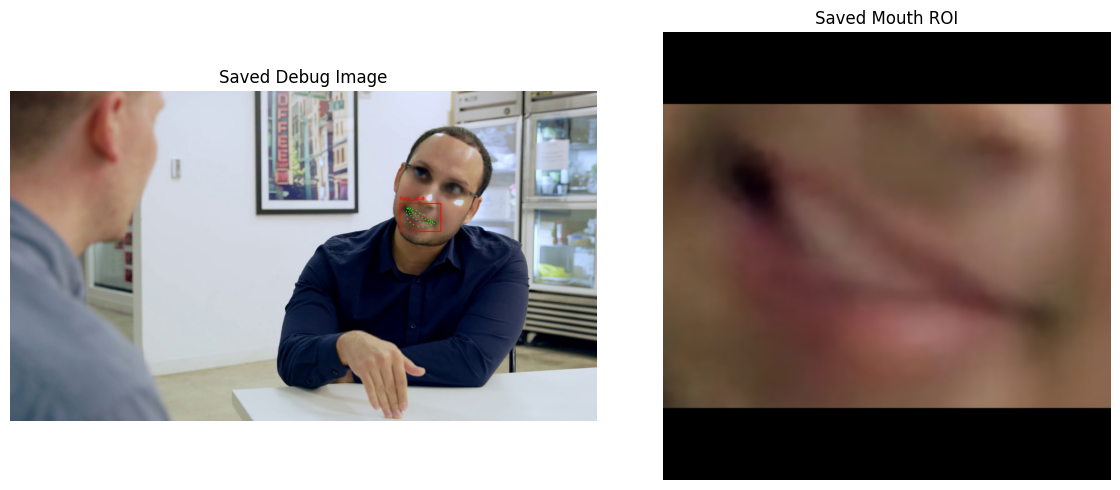


✓ CELL 7 TAMAMLANDI


In [24]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 7 - Single Frame Full Pipeline Test
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Cell 5'te bulduğumuz TEST_FRAME_PATH görüntüsünü kullanmak.
# 2) Görüntünün label ve split bilgisini otomatik belirlemek.
# 3) process_frame() fonksiyonunu çalıştırmak.
# 4) Mouth ROI / debug / landmarks dosyalarını gerçekten Drive'a yazmak.
# 5) Dönen metadata satırlarını ekranda göstermek.
#
# ÖNEMLİ:
# Henüz tüm dataset işlenmez.
# Sadece 1 frame gerçek çıktı testi yapılır.


print("=" * 70)
print("TEK FRAME - TAM PIPELINE TESTİ")
print("=" * 70)


# ==========================================================
# 1. TEST FRAME LABEL VE SPLIT BİLGİSİNİ BUL
# ==========================================================

# TEST_FRAME_PATH örneğin şöyle olabilir:
#
# .../Deney 1 Frame/Fake/train/fake_train_01130.jpg
#
# Biz relative path üzerinden:
# - Fake -> fake
# - train -> train
#
# bilgilerini çıkaracağız.


relative_parts = TEST_FRAME_PATH.relative_to(
    INPUT_ROOT
).parts


print("\nRelative path parçaları:")
print(relative_parts)


# En az:
# ('Fake', 'train', 'dosya.jpg')
# gibi bir yapı bekliyoruz.

if len(relative_parts) < 3:
    raise RuntimeError(
        "Test frame yolu beklenen klasör yapısında değil."
    )


label_name = relative_parts[0].lower()
split_name = relative_parts[1].lower()


# ==========================================================
# 2. LABEL DOĞRULAMA
# ==========================================================

if label_name not in {"fake", "real"}:
    raise ValueError(
        f"Geçersiz label bulundu: {label_name}"
    )


# ==========================================================
# 3. SPLIT DOĞRULAMA
# ==========================================================

if split_name not in {"train", "val", "test"}:
    raise ValueError(
        f"Geçersiz split bulundu: {split_name}"
    )


print("\nBelirlenen bilgiler:")
print(f"Label : {label_name}")
print(f"Split : {split_name}")


# ==========================================================
# 4. FRAME'İ İŞLE
# ==========================================================

test_metadata_rows = process_frame(
    frame_path=TEST_FRAME_PATH,
    label=label_name,
    split=split_name
)


# ==========================================================
# 5. SONUÇ KONTROLÜ
# ==========================================================

print("\nDönen metadata satır sayısı:")
print(len(test_metadata_rows))


# Eğer birden fazla yüz varsa birden fazla satır gelebilir.
# Her yüz ayrı sample_id alır.

test_metadata_df = pd.DataFrame(
    test_metadata_rows
)


print("\nMetadata:")
display(test_metadata_df)


# ==========================================================
# 6. BAŞARILI KAYITLARI KONTROL ET
# ==========================================================

success_rows = test_metadata_df[
    test_metadata_df["status"] == "SUCCESS"
]


print("\nBaşarılı kayıt sayısı:")
print(len(success_rows))


if len(success_rows) == 0:

    print(
        "\n⚠ UYARI: Bu frame için başarılı Mouth ROI üretilemedi."
    )

else:

    print(
        "\n✓ En az bir Mouth ROI başarıyla üretildi."
    )


# ==========================================================
# 7. DOSYA YOLLARINI KONTROL ET
# ==========================================================

for _, row in success_rows.iterrows():

    print("\n" + "-" * 60)

    print("Sample ID:")
    print(row["sample_id"])

    print("\nMouth ROI:")
    print(row["mouth_path"])
    print(
        "Dosya mevcut mu? ->",
        Path(row["mouth_path"]).exists()
    )

    print("\nLandmarks:")
    print(row["landmarks_path"])
    print(
        "Dosya mevcut mu? ->",
        Path(row["landmarks_path"]).exists()
    )

    print("\nDebug:")
    print(row["debug_path"])

    if pd.notna(row["debug_path"]):

        print(
            "Dosya mevcut mu? ->",
            Path(row["debug_path"]).exists()
        )


# ==========================================================
# 8. TEST ÇIKTISINI GÖRSEL OLARAK GÖSTER
# ==========================================================

# İlk başarılı örneği gösteriyoruz.

if len(success_rows) > 0:

    first_success = success_rows.iloc[0]

    mouth_image = cv2.imread(
        first_success["mouth_path"]
    )

    debug_image = cv2.imread(
        first_success["debug_path"]
    )


    if mouth_image is not None:

        mouth_image_rgb = cv2.cvtColor(
            mouth_image,
            cv2.COLOR_BGR2RGB
        )


    if debug_image is not None:

        debug_image_rgb = cv2.cvtColor(
            debug_image,
            cv2.COLOR_BGR2RGB
        )


    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5)
    )


    if debug_image is not None:

        axes[0].imshow(
            debug_image_rgb
        )

        axes[0].set_title(
            "Saved Debug Image"
        )

    axes[0].axis("off")


    if mouth_image is not None:

        axes[1].imshow(
            mouth_image_rgb
        )

        axes[1].set_title(
            "Saved Mouth ROI"
        )

    axes[1].axis("off")


    plt.tight_layout()
    plt.show()


# ==========================================================
# 9. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)
print("✓ CELL 7 TAMAMLANDI")
print("=" * 70)

In [25]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 8 - Metadata, Statistics and Run Configuration
# ==========================================================

# Bu hücrenin amacı:
#
# 1) process_frame() fonksiyonundan gelen metadata kayıtlarını
#    ilgili split metadata.csv dosyasına yazmak.
#
# 2) Aynı kayıtları genel:
#
#       mouth_roi_output/metadata.csv
#
#    dosyasına da eklemek.
#
# 3) Her:
#
#       fake / real
#       train / val / test
#
#    kombinasyonu için statistics.json dosyasını güncellemek.
#
# 4) Çalışmanın parametrelerini run_config.json içinde saklamak.
#
# Bu hücre henüz bütün dataset'i işlemeye başlamaz.


print("=" * 70)
print("METADATA + STATISTICS + RUN CONFIG HAZIRLANIYOR")
print("=" * 70)


# ==========================================================
# 1. METADATA KOLONLARINI KONTROL ET
# ==========================================================

# METADATA_COLUMNS daha önce Cell 3'te tanımlandı.
#
# process_frame() fonksiyonunun ürettiği kayıtlar
# bu kolon sırasına göre CSV dosyasına yazılacaktır.

print(
    f"\nMetadata kolon sayısı: "
    f"{len(METADATA_COLUMNS)}"
)


# ==========================================================
# 2. METADATA SATIRLARINI NORMALİZE ET
# ==========================================================

def normalize_metadata_rows(metadata_rows):
    """
    process_frame() tarafından üretilen metadata kayıtlarını
    DataFrame formatına dönüştürür.

    Eksik kolon varsa otomatik olarak ekler.

    Fazladan kolon varsa METADATA_COLUMNS sırasına göre
    yalnızca gerekli kolonları seçer.

    Parametre
    ----------
    metadata_rows : list
        process_frame() çıktısı.

    Döndürür
    --------
    pandas.DataFrame
        Standart metadata tablosu.
    """

    # Liste boşsa boş DataFrame döndür.
    if metadata_rows is None or len(metadata_rows) == 0:

        return pd.DataFrame(
            columns=METADATA_COLUMNS
        )


    # Kayıtları DataFrame'e dönüştür.
    df = pd.DataFrame(
        metadata_rows
    )


    # ------------------------------------------------------
    # Eksik kolonları ekle
    # ------------------------------------------------------

    for column in METADATA_COLUMNS:

        if column not in df.columns:

            df[column] = None


    # ------------------------------------------------------
    # Kolon sırasını standartlaştır
    # ------------------------------------------------------

    df = df[
        METADATA_COLUMNS
    ]


    return df


# ==========================================================
# 3. METADATA CSV'YE GÜVENLİ ŞEKİLDE EKLE
# ==========================================================

def append_metadata_csv(
    csv_path,
    metadata_rows
):
    """
    Metadata kayıtlarını belirtilen CSV dosyasına ekler.

    Aynı sample_id daha önce CSV'de bulunuyorsa
    tekrar eklemez.

    Böylece Colab oturumu kesilir ve notebook tekrar
    çalıştırılırsa duplicate kayıt oluşması azaltılır.

    Parametreler
    ------------
    csv_path : Path
        Metadata CSV dosyasının yolu.

    metadata_rows : list
        Eklenecek metadata kayıtları.

    Döndürür
    --------
    int
        Gerçekten eklenen satır sayısı.
    """

    csv_path = Path(
        csv_path
    )


    # Yeni kayıtları standartlaştır.
    new_df = normalize_metadata_rows(
        metadata_rows
    )


    if len(new_df) == 0:

        return 0


    # ------------------------------------------------------
    # Mevcut CSV varsa oku
    # ------------------------------------------------------

    if csv_path.exists():

        try:

            existing_df = pd.read_csv(
                csv_path,
                encoding="utf-8-sig"
            )

        except pd.errors.EmptyDataError:

            existing_df = pd.DataFrame(
                columns=METADATA_COLUMNS
            )

    else:

        existing_df = pd.DataFrame(
            columns=METADATA_COLUMNS
        )


    # ------------------------------------------------------
    # Mevcut sample_id değerlerini bul
    # ------------------------------------------------------

    if (
        "sample_id" in existing_df.columns
        and
        len(existing_df) > 0
    ):

        existing_ids = set(
            existing_df[
                "sample_id"
            ].astype(str)
        )

    else:

        existing_ids = set()


    # ------------------------------------------------------
    # Duplicate sample_id kayıtlarını çıkar
    # ------------------------------------------------------

    rows_to_add = new_df[
        ~new_df[
            "sample_id"
        ].astype(str).isin(
            existing_ids
        )
    ].copy()


    added_count = len(
        rows_to_add
    )


    # Yeni kayıt yoksa dosyaya dokunma.
    if added_count == 0:

        return 0


    # ------------------------------------------------------
    # Mevcut + yeni kayıtları birleştir
    # ------------------------------------------------------

    combined_df = pd.concat(
        [
            existing_df,
            rows_to_add
        ],
        ignore_index=True
    )


    # Kolon sırasını yine garanti et.
    for column in METADATA_COLUMNS:

        if column not in combined_df.columns:

            combined_df[column] = None


    combined_df = combined_df[
        METADATA_COLUMNS
    ]


    # ------------------------------------------------------
    # CSV'yi güvenli şekilde tekrar yaz
    # ------------------------------------------------------

    combined_df.to_csv(
        csv_path,
        index=False,
        encoding="utf-8-sig"
    )


    return added_count


# ==========================================================
# 4. SPLIT METADATA + GLOBAL METADATA GÜNCELLE
# ==========================================================

def save_metadata_rows(
    metadata_rows,
    label,
    split
):
    """
    Metadata kayıtlarını iki ayrı yere yazar:

    1) Split metadata:
       fake/train/metadata.csv

    2) Global metadata:
       mouth_roi_output/metadata.csv

    Parametreler
    ------------
    metadata_rows : list
        process_frame() sonucu.

    label : str
        fake veya real.

    split : str
        train, val veya test.
    """

    split_root = (
        OUTPUT_ROOT
        / label
        / split
    )


    split_metadata_path = (
        split_root
        / "metadata.csv"
    )


    global_metadata_path = (
        OUTPUT_ROOT
        / "metadata.csv"
    )


    # ------------------------------------------------------
    # Split metadata
    # ------------------------------------------------------

    split_added = append_metadata_csv(
        split_metadata_path,
        metadata_rows
    )


    # ------------------------------------------------------
    # Global metadata
    # ------------------------------------------------------

    global_added = append_metadata_csv(
        global_metadata_path,
        metadata_rows
    )


    return {
        "split_added": int(
            split_added
        ),

        "global_added": int(
            global_added
        )
    }


# ==========================================================
# 5. STATISTICS HESAPLAMA
# ==========================================================

def calculate_split_statistics(
    label,
    split
):
    """
    Bir split'in metadata.csv dosyasından istatistik üretir.

    Örneğin:

        fake/train

    için:

    - toplam kayıt
    - başarılı ROI
    - skipped
    - error
    - yüz bulunamayan
    - ağız çıkarılamayan
    - ortalama işlem süresi

    hesaplanır.
    """

    split_root = (
        OUTPUT_ROOT
        / label
        / split
    )


    metadata_path = (
        split_root
        / "metadata.csv"
    )


    # ------------------------------------------------------
    # Metadata yoksa boş istatistik
    # ------------------------------------------------------

    if not metadata_path.exists():

        return {

            "label": label,
            "split": split,

            "total_records": 0,

            "success_count": 0,

            "skipped_count": 0,

            "error_count": 0,

            "no_face_count": 0,

            "mouth_not_detected_count": 0,

            "average_processing_ms": 0.0
        }


    # ------------------------------------------------------
    # CSV oku
    # ------------------------------------------------------

    try:

        df = pd.read_csv(
            metadata_path,
            encoding="utf-8-sig"
        )

    except pd.errors.EmptyDataError:

        df = pd.DataFrame(
            columns=METADATA_COLUMNS
        )


    # Metadata boşsa
    if len(df) == 0:

        return {

            "label": label,
            "split": split,

            "total_records": 0,

            "success_count": 0,

            "skipped_count": 0,

            "error_count": 0,

            "no_face_count": 0,

            "mouth_not_detected_count": 0,

            "average_processing_ms": 0.0
        }


    # ======================================================
    # İSTATİSTİKLER
    # ======================================================

    total_records = len(
        df
    )


    success_count = int(
        (
            df["status"] == "SUCCESS"
        ).sum()
    )


    skipped_count = int(
        (
            df["status"] == "SKIPPED"
        ).sum()
    )


    error_count = int(
        (
            df["status"] == "ERROR"
        ).sum()
    )


    # ------------------------------------------------------
    # Face bulunamayan kayıt sayısı
    # ------------------------------------------------------

    no_face_count = int(
        df[
            "error"
        ].fillna(
            ""
        ).astype(
            str
        ).str.contains(
            "NO_FACE_DETECTED",
            regex=False
        ).sum()
    )


    # ------------------------------------------------------
    # Mouth detected = false sayısı
    # ------------------------------------------------------

    mouth_detected_series = (
        df[
            "mouth_detected"
        ].astype(
            str
        ).str.lower()
    )


    mouth_not_detected_count = int(
        (
            mouth_detected_series
            != "true"
        ).sum()
    )


    # ------------------------------------------------------
    # Ortalama işlem süresi
    # ------------------------------------------------------

    processing_numeric = pd.to_numeric(
        df[
            "processing_ms"
        ],
        errors="coerce"
    )


    if (
        processing_numeric
        .notna()
        .any()
    ):

        average_processing_ms = float(
            processing_numeric.mean()
        )

    else:

        average_processing_ms = 0.0


    statistics = {

        "label": label,

        "split": split,

        "total_records": int(
            total_records
        ),

        "success_count": int(
            success_count
        ),

        "skipped_count": int(
            skipped_count
        ),

        "error_count": int(
            error_count
        ),

        "no_face_count": int(
            no_face_count
        ),

        "mouth_not_detected_count": int(
            mouth_not_detected_count
        ),

        "average_processing_ms": round(
            average_processing_ms,
            3
        )
    }


    return statistics


# ==========================================================
# 6. statistics.json GÜNCELLE
# ==========================================================

def update_statistics(
    label,
    split
):
    """
    İlgili split için statistics.json dosyasını günceller.
    """

    statistics = (
        calculate_split_statistics(
            label,
            split
        )
    )


    statistics_path = (
        OUTPUT_ROOT
        / label
        / split
        / "statistics.json"
    )


    with open(
        statistics_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            statistics,
            file,
            ensure_ascii=False,
            indent=4
        )


    return statistics


# ==========================================================
# 7. TÜM STATISTICS DOSYALARINI GÜNCELLE
# ==========================================================

def update_all_statistics():
    """
    fake/real ve train/val/test kombinasyonlarının
    tamamının statistics.json dosyasını günceller.
    """

    results = {}


    for label in LABELS:

        results[
            label
        ] = {}


        for split in SPLITS:

            stats = update_statistics(
                label,
                split
            )


            results[
                label
            ][
                split
            ] = stats


    return results


# ==========================================================
# 8. RUN CONFIG OLUŞTUR
# ==========================================================

# Çalışmanın hangi ayarlarla gerçekleştirildiğini
# kayıt altına alıyoruz.
#
# Bu dosya reproducibility açısından önemlidir.


RUN_CONFIG = {

    # ------------------------------------------------------
    # Veri yolları
    # ------------------------------------------------------

    "input_root": str(
        INPUT_ROOT
    ),

    "output_root": str(
        OUTPUT_ROOT
    ),

    "model_path": str(
        MODEL_PATH
    ),


    # ------------------------------------------------------
    # Face Landmarker ayarları
    # ------------------------------------------------------

    "num_faces": int(
        NUM_FACES
    ),

    "min_face_detection_confidence": float(
        DET_CONF
    ),

    "min_face_presence_confidence": float(
        PRESENCE_CONF
    ),

    "min_tracking_confidence": float(
        TRACKING_CONF
    ),


    # ------------------------------------------------------
    # Mouth ROI ayarları
    # ------------------------------------------------------

    "mouth_padding_ratio": float(
        MOUTH_PADDING_RATIO
    ),

    "output_size": int(
        OUTPUT_SIZE
    ),

    "resize_method": (
        "aspect_ratio_preserved_with_padding"
    ),

    "mouth_landmark_count": int(
        len(MOUTH_LANDMARKS)
    ),

    "mouth_landmark_indices": [
        int(x)
        for x in MOUTH_LANDMARKS
    ],


    # ------------------------------------------------------
    # Kayıt ayarları
    # ------------------------------------------------------

    "save_debug": bool(
        SAVE_DEBUG
    ),

    "flush_every": int(
        FLUSH_EVERY
    ),

    "overwrite": bool(
        OVERWRITE
    ),


    # ------------------------------------------------------
    # Dataset yapısı
    # ------------------------------------------------------

    "labels": LABELS,

    "splits": SPLITS,


    # ------------------------------------------------------
    # Oluşturulma zamanı
    # ------------------------------------------------------

    "created_at": time.strftime(
        "%Y-%m-%d %H:%M:%S"
    )
}


RUN_CONFIG_PATH = (
    OUTPUT_ROOT
    / "run_config.json"
)


with open(
    RUN_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        RUN_CONFIG,
        file,
        ensure_ascii=False,
        indent=4
    )


print(
    "\n✓ run_config.json oluşturuldu."
)


# ==========================================================
# 9. CELL 7 TEST SONUCUNU METADATA'YA EKLE
# ==========================================================

# Cell 7'de test_metadata_rows oluşmuştu.
#
# Eğer bu değişken hâlâ Colab belleğinde varsa
# o test kaydını gerçek metadata dosyasına ekleyebiliriz.


if "test_metadata_rows" in globals():

    print(
        "\nCell 7 test metadata kaydı bulunuyor."
    )


    metadata_result = save_metadata_rows(

        test_metadata_rows,

        label=label_name,

        split=split_name
    )


    print(
        "Split metadata'ya eklenen:",
        metadata_result[
            "split_added"
        ]
    )


    print(
        "Global metadata'ya eklenen:",
        metadata_result[
            "global_added"
        ]
    )


    # Statistics güncelle
    test_statistics = update_statistics(
        label_name,
        split_name
    )


    print(
        "\nTest split statistics:"
    )

    print(
        json.dumps(
            test_statistics,
            ensure_ascii=False,
            indent=4
        )
    )


else:

    print(
        "\nℹ test_metadata_rows bellekte bulunamadı."
    )

    print(
        "Bu sorun değil. Toplu işlem sırasında "
        "metadata otomatik üretilecektir."
    )


# ==========================================================
# 10. SON KONTROL
# ==========================================================

print("\n" + "=" * 70)

print("CELL 8 SONUÇ")

print("=" * 70)


print(
    "run_config.json mevcut mu? :",
    RUN_CONFIG_PATH.exists()
)


print(
    "global metadata mevcut mu? :",
    (
        OUTPUT_ROOT
        / "metadata.csv"
    ).exists()
)


print("\n✓ Metadata sistemi hazır.")
print("✓ Statistics sistemi hazır.")
print("✓ Run configuration hazır.")

print("\n" + "=" * 70)
print("✓ CELL 8 BAŞARIYLA TAMAMLANDI")
print("=" * 70)

METADATA + STATISTICS + RUN CONFIG HAZIRLANIYOR

Metadata kolon sayısı: 24

✓ run_config.json oluşturuldu.

Cell 7 test metadata kaydı bulunuyor.
Split metadata'ya eklenen: 1
Global metadata'ya eklenen: 1

Test split statistics:
{
    "label": "fake",
    "split": "train",
    "total_records": 2,
    "success_count": 2,
    "skipped_count": 0,
    "error_count": 0,
    "no_face_count": 0,
    "mouth_not_detected_count": 0,
    "average_processing_ms": 232.9
}

CELL 8 SONUÇ
run_config.json mevcut mu? : True
global metadata mevcut mu? : True

✓ Metadata sistemi hazır.
✓ Statistics sistemi hazır.
✓ Run configuration hazır.

✓ CELL 8 BAŞARIYLA TAMAMLANDI


In [26]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 9 - Full Dataset Processing
# ==========================================================

# Bu hücre projenin ana toplu işleme aşamasıdır.
#
# Akış:
#
# Deney 1 Frame
#       |
#       +-- Fake
#       |    +-- train
#       |    +-- val
#       |    +-- test
#       |
#       +-- Real
#            +-- train
#            +-- val
#            +-- test
#
# Her frame:
#
# Frame
#   ↓
# Face Landmarker
#   ↓
# Mouth Landmarks
#   ↓
# Bounding Box
#   ↓
# Padding
#   ↓
# Mouth Crop
#   ↓
# Aspect Ratio Preserved Resize
#   ↓
# mouth/
# debug/
# landmarks/
# metadata.csv
#
# ----------------------------------------------------------
# ÖNEMLİ:
#
# İlk kez çalıştırıyorsan bütün dataset işlenecektir.
#
# Notebook yarıda kalırsa aynı hücre tekrar çalıştırılabilir.
# Mevcut mouth çıktıları OVERWRITE=False olduğu için
# gereksiz yere üzerine yazılmaz.
# ==========================================================


print("=" * 75)
print("MOUTH ROI - TÜM DATASET İŞLEME")
print("=" * 75)


# ==========================================================
# 1. DESTEKLENEN GÖRÜNTÜ FORMATLARI
# ==========================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


# ==========================================================
# 2. INPUT KLASÖR EŞLEŞMESİ
# ==========================================================
#
# Input tarafında klasörler:
#
# Fake
# Real
#
# Output tarafında ise:
#
# fake
# real
#
# kullanıyoruz.

INPUT_LABEL_FOLDER = {
    "fake": "Fake",
    "real": "Real"
}


# ==========================================================
# 3. SPLIT'TEKİ TÜM FRAME'LERİ BUL
# ==========================================================

def collect_frames(
    label,
    split
):
    """
    Belirtilen label ve split içerisindeki bütün görüntüleri
    alt klasörler dahil bulur.

    Örnek
    -----
    label = 'fake'
    split = 'train'

    Aranan klasör:
    INPUT_ROOT/Fake/train
    """

    input_label_name = (
        INPUT_LABEL_FOLDER[label]
    )


    split_input_root = (
        INPUT_ROOT
        / input_label_name
        / split
    )


    # Klasör yoksa ciddi bir yapı problemi vardır.
    if not split_input_root.exists():

        print(
            f"⚠ Klasör bulunamadı: "
            f"{split_input_root}"
        )

        return []


    frame_paths = []


    # Alt klasörler dahil tara.
    for path in split_input_root.rglob("*"):

        if (
            path.is_file()
            and
            path.suffix.lower()
            in IMAGE_EXTENSIONS
        ):

            frame_paths.append(
                path
            )


    # Her çalıştırmada aynı sırayla ilerlemek için sırala.
    frame_paths = sorted(
        frame_paths,
        key=lambda x: str(x)
    )


    return frame_paths


# ==========================================================
# 4. DATASET SAYILARINI ÖNCEDEN KONTROL ET
# ==========================================================

dataset_counts = {}


print("\n" + "=" * 75)
print("INPUT DATASET KONTROLÜ")
print("=" * 75)


grand_total_frames = 0


for label in LABELS:

    dataset_counts[label] = {}


    print(
        f"\n{label.upper()}"
    )


    for split in SPLITS:

        frames = collect_frames(
            label,
            split
        )


        count = len(
            frames
        )


        dataset_counts[
            label
        ][
            split
        ] = count


        grand_total_frames += count


        print(
            f"  {split:<5}: "
            f"{count} frame"
        )


print(
    "\nToplam bulunan frame:",
    grand_total_frames
)


# ----------------------------------------------------------
# 3000 bekliyoruz fakat burada zorla hata vermiyoruz.
#
# Çünkü ileride veri sayısı değişebilir.
# Sadece kullanıcıyı uyarıyoruz.
# ----------------------------------------------------------

if grand_total_frames != 3000:

    print(
        "\n⚠ UYARI:"
    )

    print(
        f"Beklenen yaklaşık 3000 frame yerine "
        f"{grand_total_frames} görüntü bulundu."
    )

    print(
        "Toplu işleme başlamadan önce sayıların doğru "
        "olduğundan emin ol."
    )

else:

    print(
        "\n✓ Beklenen 3000 frame bulundu."
    )


# ==========================================================
# 5. DAHA ÖNCE BAŞARILI İŞLENMİŞ FRAME'LERİ BUL
# ==========================================================

def load_processed_frame_keys(
    label,
    split
):
    """
    Split metadata.csv içerisinden daha önce SUCCESS olmuş
    frame'leri belirler.

    Bir frame birden fazla yüz içerebileceği için burada
    source_frame bazında kontrol yapılır.

    Böylece notebook yarıda kalıp yeniden başlatılırsa
    daha önce başarıyla tamamlanan frameler atlanabilir.
    """

    metadata_path = (
        OUTPUT_ROOT
        / label
        / split
        / "metadata.csv"
    )


    if not metadata_path.exists():

        return set()


    try:

        df = pd.read_csv(
            metadata_path,
            encoding="utf-8-sig"
        )

    except pd.errors.EmptyDataError:

        return set()


    if len(df) == 0:

        return set()


    # Yalnızca SUCCESS kayıtlarını dikkate al.
    successful_df = df[
        df["status"] == "SUCCESS"
    ]


    if len(successful_df) == 0:

        return set()


    return set(
        successful_df[
            "source_frame"
        ].astype(str)
    )


# ==========================================================
# 6. TEK SPLIT'İ TAMAMEN İŞLE
# ==========================================================

def process_dataset_split(
    label,
    split
):
    """
    Bir label/split kombinasyonundaki bütün frameleri işler.

    Örnek:
        fake / train

    Her FLUSH_EVERY frame'de metadata diske yazılır.
    """

    print(
        "\n"
        + "=" * 75
    )

    print(
        f"İŞLENİYOR -> "
        f"{label.upper()} / {split.upper()}"
    )

    print(
        "=" * 75
    )


    # ------------------------------------------------------
    # Frame listesini al
    # ------------------------------------------------------

    frame_paths = collect_frames(
        label,
        split
    )


    total_frames = len(
        frame_paths
    )


    print(
        f"Toplam frame: "
        f"{total_frames}"
    )


    if total_frames == 0:

        print(
            "⚠ Bu split içerisinde görüntü bulunamadı."
        )

        return {
            "label": label,
            "split": split,
            "total_frames": 0,
            "newly_processed": 0,
            "already_processed": 0,
            "metadata_rows": 0
        }


    # ------------------------------------------------------
    # Önceden işlenen frameler
    # ------------------------------------------------------

    processed_frames = (
        load_processed_frame_keys(
            label,
            split
        )
    )


    print(
        f"Daha önce başarılı işlenmiş frame: "
        f"{len(processed_frames)}"
    )


    # ------------------------------------------------------
    # Sayaçlar
    # ------------------------------------------------------

    newly_processed = 0

    already_processed = 0

    generated_metadata_rows = 0


    # Metadata'yı her frame'de Drive'a yazmak yavaştır.
    #
    # Bu yüzden önce bellekte buffer oluşturuyoruz.
    # FLUSH_EVERY = 25 olduğunda her 25 frame'de CSV'ye yazılır.

    metadata_buffer = []


    # ======================================================
    # FRAME DÖNGÜSÜ
    # ======================================================

    for frame_path in tqdm(
        frame_paths,
        desc=f"{label}/{split}",
        unit="frame"
    ):

        # --------------------------------------------------
        # Frame daha önce başarıyla işlendiyse atla
        # --------------------------------------------------

        if (
            not OVERWRITE
            and
            str(frame_path)
            in processed_frames
        ):

            already_processed += 1

            continue


        # --------------------------------------------------
        # Frame'i işle
        # --------------------------------------------------

        rows = process_frame(
            frame_path=frame_path,
            label=label,
            split=split
        )


        metadata_buffer.extend(
            rows
        )


        generated_metadata_rows += len(
            rows
        )


        newly_processed += 1


        # --------------------------------------------------
        # Periyodik Metadata Flush
        # --------------------------------------------------

        if (
            newly_processed
            % FLUSH_EVERY
            == 0
        ):

            if len(metadata_buffer) > 0:

                save_metadata_rows(
                    metadata_buffer,
                    label,
                    split
                )


                # Buffer temizle
                metadata_buffer = []


                # Statistics de güncellensin.
                update_statistics(
                    label,
                    split
                )


    # ======================================================
    # KALAN METADATA'YI YAZ
    # ======================================================

    if len(metadata_buffer) > 0:

        save_metadata_rows(
            metadata_buffer,
            label,
            split
        )


        metadata_buffer = []


    # ======================================================
    # SPLIT SONUNDA STATISTICS
    # ======================================================

    final_statistics = update_statistics(
        label,
        split
    )


    # ------------------------------------------------------
    # Sonuç
    # ------------------------------------------------------

    result = {

        "label": label,

        "split": split,

        "total_frames": int(
            total_frames
        ),

        "newly_processed": int(
            newly_processed
        ),

        "already_processed": int(
            already_processed
        ),

        "metadata_rows_generated": int(
            generated_metadata_rows
        ),

        "final_statistics": (
            final_statistics
        )
    }


    print(
        "\n✓ Split tamamlandı."
    )

    print(
        json.dumps(
            result,
            ensure_ascii=False,
            indent=4
        )
    )


    return result


# ==========================================================
# 7. TÜM DATASET
# ==========================================================

def process_full_dataset():
    """
    Fake/Real ve Train/Val/Test kombinasyonlarının tamamını
    sırasıyla işler.
    """

    print(
        "\n"
        + "#" * 75
    )

    print(
        "MOUTH ROI FULL DATASET PROCESSING BAŞLADI"
    )

    print(
        "#" * 75
    )


    full_start_time = time.perf_counter()


    all_results = []


    # ------------------------------------------------------
    # Fake + Real
    # ------------------------------------------------------

    for label in LABELS:


        # --------------------------------------------------
        # Train + Val + Test
        # --------------------------------------------------

        for split in SPLITS:

            result = process_dataset_split(
                label,
                split
            )


            all_results.append(
                result
            )


    # ======================================================
    # TÜM STATISTICS DOSYALARINI SON KEZ GÜNCELLE
    # ======================================================

    update_all_statistics()


    # ======================================================
    # TOPLAM ÇALIŞMA SÜRESİ
    # ======================================================

    elapsed_seconds = (
        time.perf_counter()
        - full_start_time
    )


    elapsed_minutes = (
        elapsed_seconds / 60
    )


    # ======================================================
    # GENEL SONUÇ
    # ======================================================

    print(
        "\n"
        + "#" * 75
    )

    print(
        "TÜM DATASET İŞLEME TAMAMLANDI"
    )

    print(
        "#" * 75
    )


    print(
        f"\nToplam süre: "
        f"{elapsed_minutes:.2f} dakika"
    )


    return all_results


# ==========================================================
# 8. ÇALIŞTIRMADAN ÖNCE SON BİLGİ
# ==========================================================

print(
    "\n"
    + "=" * 75
)

print(
    "✓ Cell 9 fonksiyonları hazır."
)

print(
    "Henüz bütün dataset başlatılmadı."
)

print(
    "=" * 75
)

MOUTH ROI - TÜM DATASET İŞLEME

INPUT DATASET KONTROLÜ

FAKE
  train: 1200 frame
  val  : 150 frame
  test : 150 frame

REAL
  train: 1200 frame
  val  : 150 frame
  test : 150 frame

Toplam bulunan frame: 3000

✓ Beklenen 3000 frame bulundu.

✓ Cell 9 fonksiyonları hazır.
Henüz bütün dataset başlatılmadı.


In [27]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 10 - Run Full Dataset Processing
# ==========================================================

# ==========================================================
# BU HÜCRE GERÇEK TOPLU İŞLEMİ BAŞLATIR
# ==========================================================
#
# Cell 9'a kadar yalnızca:
#
# - fonksiyonları hazırladık,
# - klasörleri kontrol ettik,
# - frame sayılarını saydık.
#
# Bu hücre çalıştırıldığında ise:
#
#                 3000 FRAME
#                     ↓
#             MediaPipe Face Landmarker
#                     ↓
#               Mouth Landmarks
#                     ↓
#                Mouth Bounding Box
#                     ↓
#                    Padding
#                     ↓
#                 Mouth Crop
#                     ↓
#         Aspect-Ratio Preserved Resize
#                     ↓
#                  224 x 224
#                     ↓
#       ┌─────────────┼─────────────┐
#       ↓             ↓             ↓
#     mouth/       landmarks/      debug/
#
#                     ↓
#                metadata.csv
#
#                     ↓
#               statistics.json
#
#
# Dataset sırası:
#
# fake/train
# fake/val
# fake/test
# real/train
# real/val
# real/test
#
# şeklinde olacaktır.
#
# ==========================================================


print("=" * 75)
print("MOUTH ROI - FULL DATASET PROCESSING")
print("=" * 75)

print("\nToplu işlem başlatılıyor...")

print(
    f"Toplam işlenecek frame: "
    f"{grand_total_frames}"
)

print(
    f"Output klasörü:\n"
    f"{OUTPUT_ROOT}"
)

print(
    f"\nOutput size: "
    f"{OUTPUT_SIZE}x{OUTPUT_SIZE}"
)

print(
    f"Mouth padding ratio: "
    f"{MOUTH_PADDING_RATIO}"
)

print(
    f"Metadata flush aralığı: "
    f"{FLUSH_EVERY} frame"
)

print(
    f"Overwrite: "
    f"{OVERWRITE}"
)

print("\n" + "-" * 75)


# ==========================================================
# 1. TOPLU İŞLEM BAŞLANGIÇ ZAMANI
# ==========================================================

cell10_start_time = time.perf_counter()


# ==========================================================
# 2. TÜM DATASET'İ İŞLE
# ==========================================================
#
# process_full_dataset() fonksiyonu Cell 9'da tanımlandı.
#
# Bu fonksiyon:
#
# fake/train
# fake/val
# fake/test
# real/train
# real/val
# real/test
#
# bölümlerinin tamamını otomatik olarak işleyecektir.


try:

    full_results = process_full_dataset()

    processing_completed = True


except KeyboardInterrupt:

    # ------------------------------------------------------
    # Kullanıcı işlemi manuel olarak durdurursa
    # notebook tamamen çökmesin.
    # ------------------------------------------------------

    processing_completed = False

    print("\n")
    print("!" * 75)

    print(
        "İŞLEM KULLANICI TARAFINDAN DURDURULDU."
    )

    print(
        "Daha önce diske yazılmış ROI ve metadata "
        "dosyaları korunmaktadır."
    )

    print(
        "Daha sonra Cell 10 yeniden çalıştırılabilir."
    )

    print("!" * 75)


except Exception as error:

    # ------------------------------------------------------
    # Beklenmeyen genel hata
    # ------------------------------------------------------

    processing_completed = False

    print("\n")
    print("!" * 75)

    print(
        "TOPLU İŞLEM SIRASINDA BEKLENMEYEN HATA"
    )

    print("!" * 75)

    print(
        f"Hata tipi: "
        f"{type(error).__name__}"
    )

    print(
        f"Hata mesajı: "
        f"{str(error)}"
    )

    # Hatayı tekrar yükselt.
    # Böylece Colab traceback'i de gösterir.
    raise


# ==========================================================
# 3. TOPLAM CELL ÇALIŞMA SÜRESİ
# ==========================================================

cell10_elapsed_seconds = (
    time.perf_counter()
    - cell10_start_time
)


cell10_elapsed_minutes = (
    cell10_elapsed_seconds / 60
)


# ==========================================================
# 4. İŞLEM TAMAMLANDIYSA İSTATİSTİKLERİ SON KEZ GÜNCELLE
# ==========================================================

if processing_completed:

    print("\n")
    print("=" * 75)
    print("SON İSTATİSTİKLER GÜNCELLENİYOR")
    print("=" * 75)


    final_statistics = (
        update_all_statistics()
    )


    print(
        "✓ Tüm statistics.json dosyaları güncellendi."
    )


# ==========================================================
# 5. SPLIT BAZLI ÖZET TABLO
# ==========================================================

if processing_completed:

    summary_rows = []


    for label in LABELS:

        for split in SPLITS:

            stats = (
                final_statistics[
                    label
                ][
                    split
                ]
            )


            summary_rows.append({

                "label": label,

                "split": split,

                "input_frames": (
                    dataset_counts[
                        label
                    ][
                        split
                    ]
                ),

                "metadata_records": (
                    stats[
                        "total_records"
                    ]
                ),

                "successful_roi": (
                    stats[
                        "success_count"
                    ]
                ),

                "skipped": (
                    stats[
                        "skipped_count"
                    ]
                ),

                "errors": (
                    stats[
                        "error_count"
                    ]
                ),

                "no_face": (
                    stats[
                        "no_face_count"
                    ]
                ),

                "mouth_not_detected": (
                    stats[
                        "mouth_not_detected_count"
                    ]
                ),

                "avg_processing_ms": (
                    stats[
                        "average_processing_ms"
                    ]
                )
            })


    summary_df = pd.DataFrame(
        summary_rows
    )


    print("\n")
    print("=" * 75)
    print("DATASET İŞLEME ÖZETİ")
    print("=" * 75)

    display(
        summary_df
    )


# ==========================================================
# 6. GENEL SAYILAR
# ==========================================================

if processing_completed:

    total_success = int(
        summary_df[
            "successful_roi"
        ].sum()
    )


    total_skipped = int(
        summary_df[
            "skipped"
        ].sum()
    )


    total_errors = int(
        summary_df[
            "errors"
        ].sum()
    )


    total_no_face = int(
        summary_df[
            "no_face"
        ].sum()
    )


    total_metadata_records = int(
        summary_df[
            "metadata_records"
        ].sum()
    )


    print("\n")
    print("=" * 75)
    print("GENEL SONUÇ")
    print("=" * 75)


    print(
        f"Input frame sayısı        : "
        f"{grand_total_frames}"
    )


    print(
        f"Metadata kayıt sayısı     : "
        f"{total_metadata_records}"
    )


    print(
        f"Başarılı Mouth ROI        : "
        f"{total_success}"
    )


    print(
        f"Atlanan kayıt             : "
        f"{total_skipped}"
    )


    print(
        f"Hatalı kayıt              : "
        f"{total_errors}"
    )


    print(
        f"Yüz bulunamayan kayıt     : "
        f"{total_no_face}"
    )


    print(
        f"Toplam çalışma süresi     : "
        f"{cell10_elapsed_minutes:.2f} dakika"
    )


# ==========================================================
# 7. OUTPUT DOSYALARINI KONTROL ET
# ==========================================================

if processing_completed:

    global_metadata_path = (
        OUTPUT_ROOT
        / "metadata.csv"
    )


    run_config_path = (
        OUTPUT_ROOT
        / "run_config.json"
    )


    print("\n")
    print("=" * 75)
    print("OUTPUT DOSYA KONTROLÜ")
    print("=" * 75)


    print(
        "Global metadata.csv :",
        global_metadata_path.exists()
    )


    print(
        "run_config.json     :",
        run_config_path.exists()
    )


    # ------------------------------------------------------
    # Her split'teki Mouth ROI dosya sayısını say
    # ------------------------------------------------------

    print("\nMouth ROI dosya sayıları:")


    for label in LABELS:

        for split in SPLITS:

            mouth_folder = (
                OUTPUT_ROOT
                / label
                / split
                / "mouth"
            )


            mouth_count = len(
                list(
                    mouth_folder.glob(
                        "*.png"
                    )
                )
            )


            print(
                f"{label}/{split:<5} -> "
                f"{mouth_count} ROI"
            )


# ==========================================================
# 8. GENEL ÖZET JSON DOSYASI OLUŞTUR
# ==========================================================

if processing_completed:

    processing_summary = {

        "total_input_frames": int(
            grand_total_frames
        ),

        "total_metadata_records": int(
            total_metadata_records
        ),

        "successful_mouth_roi": int(
            total_success
        ),

        "skipped_records": int(
            total_skipped
        ),

        "error_records": int(
            total_errors
        ),

        "no_face_records": int(
            total_no_face
        ),

        "elapsed_seconds": round(
            float(
                cell10_elapsed_seconds
            ),
            3
        ),

        "elapsed_minutes": round(
            float(
                cell10_elapsed_minutes
            ),
            3
        ),

        "output_size": int(
            OUTPUT_SIZE
        ),

        "mouth_padding_ratio": float(
            MOUTH_PADDING_RATIO
        ),

        "completed_at": time.strftime(
            "%Y-%m-%d %H:%M:%S"
        )
    }


    processing_summary_path = (
        OUTPUT_ROOT
        / "processing_summary.json"
    )


    with open(
        processing_summary_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            processing_summary,
            file,
            ensure_ascii=False,
            indent=4
        )


    print(
        "\n✓ processing_summary.json oluşturuldu."
    )


# ==========================================================
# 9. CELL 10 SONUCU
# ==========================================================

print("\n")
print("#" * 75)


if processing_completed:

    print(
        "✓ CELL 10 BAŞARIYLA TAMAMLANDI"
    )

    print(
        "✓ TÜM DATASET İŞLENDİ"
    )

    print(
        "✓ MOUTH ROI DATASET HAZIR"
    )


else:

    print(
        "⚠ CELL 10 TAMAMLANMADAN DURDU"
    )

    print(
        "Daha önce kaydedilen veriler korunuyor."
    )


print("#" * 75)

MOUTH ROI - FULL DATASET PROCESSING

Toplu işlem başlatılıyor...
Toplam işlenecek frame: 3000
Output klasörü:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output

Output size: 224x224
Mouth padding ratio: 0.25
Metadata flush aralığı: 25 frame
Overwrite: False

---------------------------------------------------------------------------

###########################################################################
MOUTH ROI FULL DATASET PROCESSING BAŞLADI
###########################################################################

İŞLENİYOR -> FAKE / TRAIN
Toplam frame: 1200
Daha önce başarılı işlenmiş frame: 1


fake/train: 100%|██████████| 1200/1200 [03:04<00:00,  6.52frame/s]



✓ Split tamamlandı.
{
    "label": "fake",
    "split": "train",
    "total_frames": 1200,
    "newly_processed": 1199,
    "already_processed": 1,
    "metadata_rows_generated": 1252,
    "final_statistics": {
        "label": "fake",
        "split": "train",
        "total_records": 1254,
        "success_count": 1192,
        "skipped_count": 62,
        "error_count": 0,
        "no_face_count": 62,
        "mouth_not_detected_count": 62,
        "average_processing_ms": 82.204
    }
}

İŞLENİYOR -> FAKE / VAL
Toplam frame: 150
Daha önce başarılı işlenmiş frame: 0


fake/val:  15%|█▌        | 23/150 [00:05<00:15,  8.06frame/s]/tmp/ipykernel_2706/3780938200.py:233: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(
fake/val: 100%|██████████| 150/150 [00:21<00:00,  6.99frame/s]



✓ Split tamamlandı.
{
    "label": "fake",
    "split": "val",
    "total_frames": 150,
    "newly_processed": 150,
    "already_processed": 0,
    "metadata_rows_generated": 154,
    "final_statistics": {
        "label": "fake",
        "split": "val",
        "total_records": 154,
        "success_count": 141,
        "skipped_count": 13,
        "error_count": 0,
        "no_face_count": 13,
        "mouth_not_detected_count": 13,
        "average_processing_ms": 81.465
    }
}

İŞLENİYOR -> FAKE / TEST
Toplam frame: 150
Daha önce başarılı işlenmiş frame: 0


...


✓ Split tamamlandı.
{
    "label": "real",
    "split": "val",
    "total_frames": 150,
    "newly_processed": 150,
    "already_processed": 0,
    "metadata_rows_generated": 155,
    "final_statistics": {
        "label": "real",
        "split": "val",
        "total_records": 155,
        "success_count": 155,
        "skipped_count": 0,
        "error_count": 0,
        "no_face_count": 0,
        "mouth_not_detected_count": 0,
        "average_processing_ms": 77.328
    }
}

İŞLENİYOR -> REAL / TEST
Toplam frame: 150
Daha önce başarılı işlenmiş frame: 0


real/test:  16%|█▌        | 24/150 [00:05<00:12, 10.27frame/s]/tmp/ipykernel_2706/3780938200.py:233: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(
real/test: 100%|██████████| 150/150 [00:21<00:00,  7.03frame/s]



✓ Split tamamlandı.
{
    "label": "real",
    "split": "test",
    "total_frames": 150,
    "newly_processed": 150,
    "already_processed": 0,
    "metadata_rows_generated": 151,
    "final_statistics": {
        "label": "real",
        "split": "test",
        "total_records": 151,
        "success_count": 146,
        "skipped_count": 5,
        "error_count": 0,
        "no_face_count": 5,
        "mouth_not_detected_count": 5,
        "average_processing_ms": 65.449
    }
}

###########################################################################
TÜM DATASET İŞLEME TAMAMLANDI
###########################################################################

Toplam süre: 8.12 dakika


SON İSTATİSTİKLER GÜNCELLENİYOR
✓ Tüm statistics.json dosyaları güncellendi.


DATASET İŞLEME ÖZETİ


,label,split,input_frames,metadata_records,successful_roi,skipped,errors,no_face,mouth_not_detected,avg_processing_ms
0,fake,train,1200,1254,1192,62,0,62,62,82.204
1,fake,val,150,154,141,13,0,13,13,81.465
2,fake,test,150,159,156,3,0,3,3,76.242
3,real,train,1200,1225,1197,28,0,28,28,114.955
4,real,val,150,155,155,0,0,0,0,77.328
5,real,test,150,151,146,5,0,5,5,65.449




GENEL SONUÇ
Input frame sayısı        : 3000
Metadata kayıt sayısı     : 3098
Başarılı Mouth ROI        : 2987
Atlanan kayıt             : 111
Hatalı kayıt              : 0
Yüz bulunamayan kayıt     : 111
Toplam çalışma süresi     : 8.12 dakika


OUTPUT DOSYA KONTROLÜ
Global metadata.csv : True
run_config.json     : True

Mouth ROI dosya sayıları:
fake/train -> 1192 ROI
fake/val   -> 141 ROI
fake/test  -> 156 ROI
real/train -> 1197 ROI
real/val   -> 155 ROI
real/test  -> 146 ROI

✓ processing_summary.json oluşturuldu.


###########################################################################
✓ CELL 10 BAŞARIYLA TAMAMLANDI
✓ TÜM DATASET İŞLENDİ
✓ MOUTH ROI DATASET HAZIR
###########################################################################


MOUTH ROI - FINAL QUALITY CONTROL

Global metadata kayıt sayısı: 3098

METADATA DURUM DAĞILIMI
status
SUCCESS    2987
SKIPPED     111
Name: count, dtype: int64

LABEL DAĞILIMI
label
fake    1567
real    1531
Name: count, dtype: int64

SPLIT DAĞILIMI
split
train    2479
test      310
val       309
Name: count, dtype: int64

LABEL / SPLIT DAĞILIMI


split,test,train,val
label,,,
fake,159,1254,154
real,151,1225,155



Başarılı Mouth ROI metadata kaydı: 2987
Hatalı metadata kaydı: 0
Atlanan metadata kaydı: 111

✓ ERROR kaydı bulunmuyor.

SKIPPED NEDENLERİ
error
NO_FACE_DETECTED    111
Name: count, dtype: int64

DOSYA VARLIK KONTROLÜ
Eksik Mouth ROI: 0
Eksik Landmark JSON: 0
Eksik Debug: 0

SAMPLE ID KONTROLÜ
Duplicate sample_id sayısı: 0
✓ sample_id değerleri benzersiz.

MOUTH ROI DOSYA SAYILARI


,label,split,mouth_roi_files
0,fake,train,1192
1,fake,val,141
2,fake,test,156
3,real,train,1197
4,real,val,155
5,real,test,146


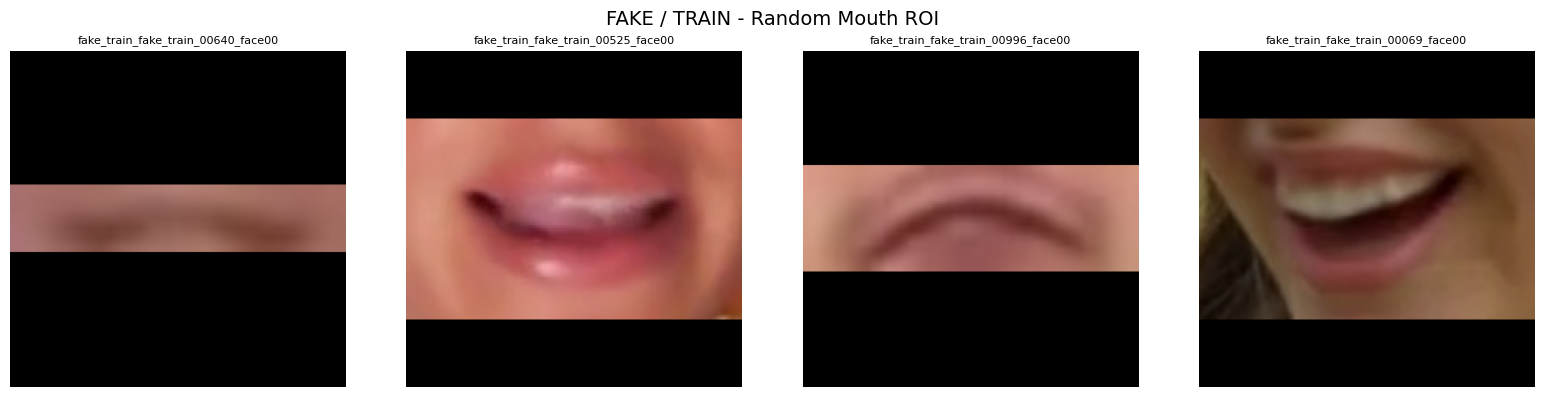

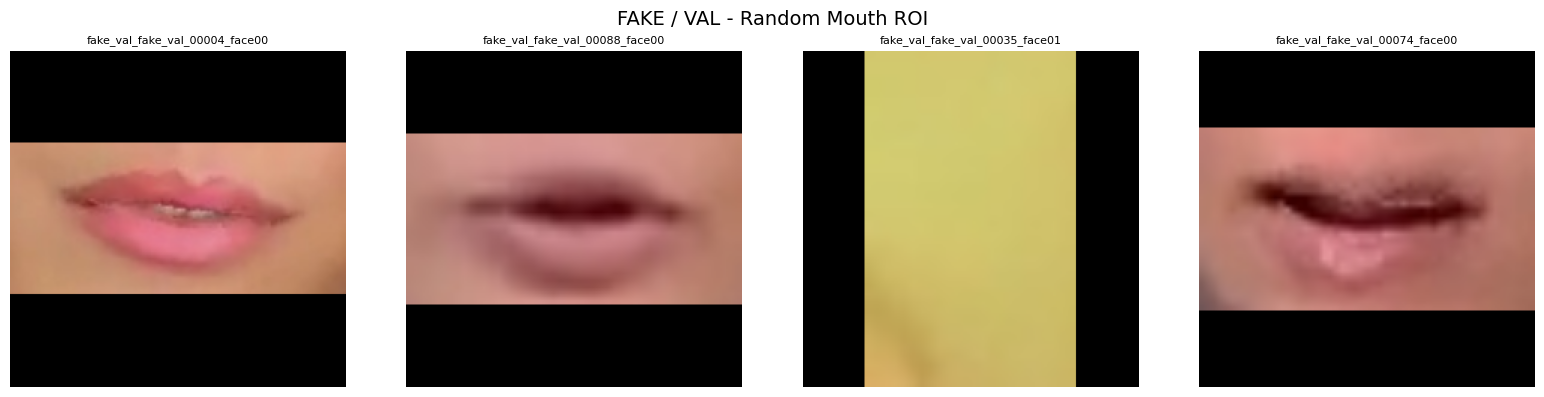

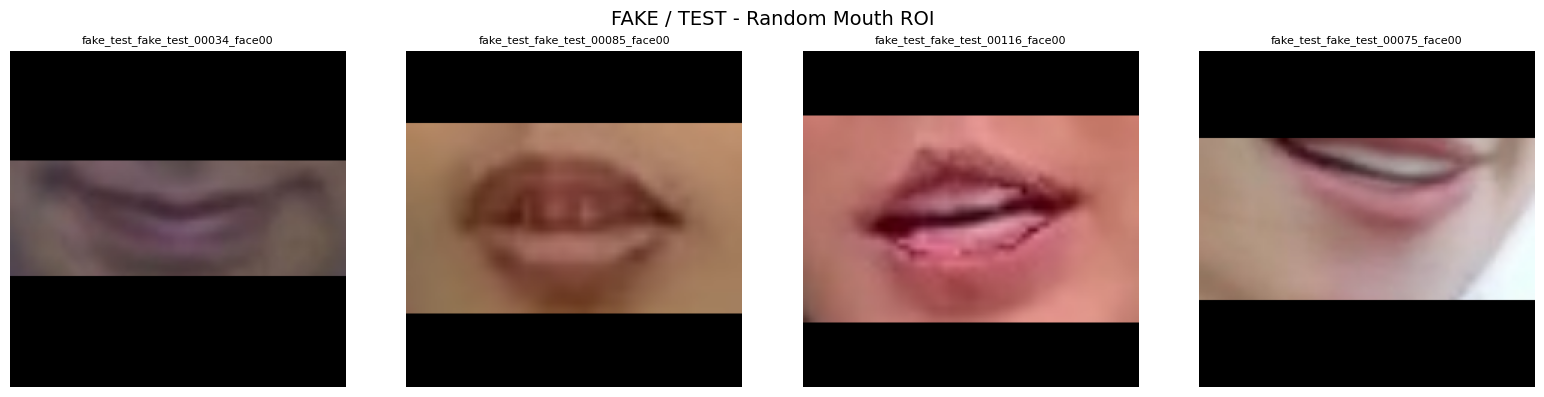

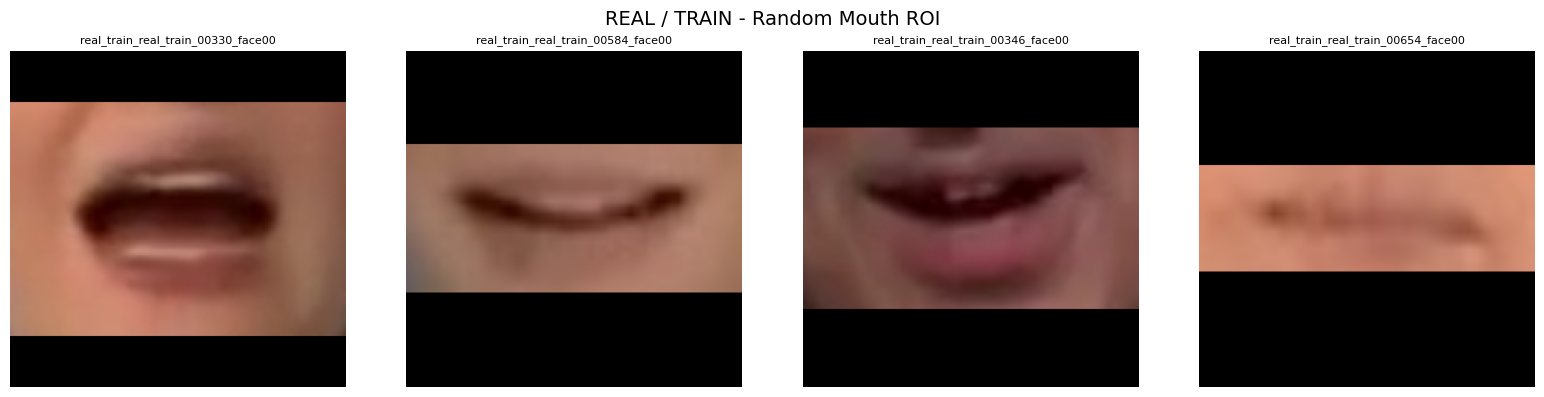

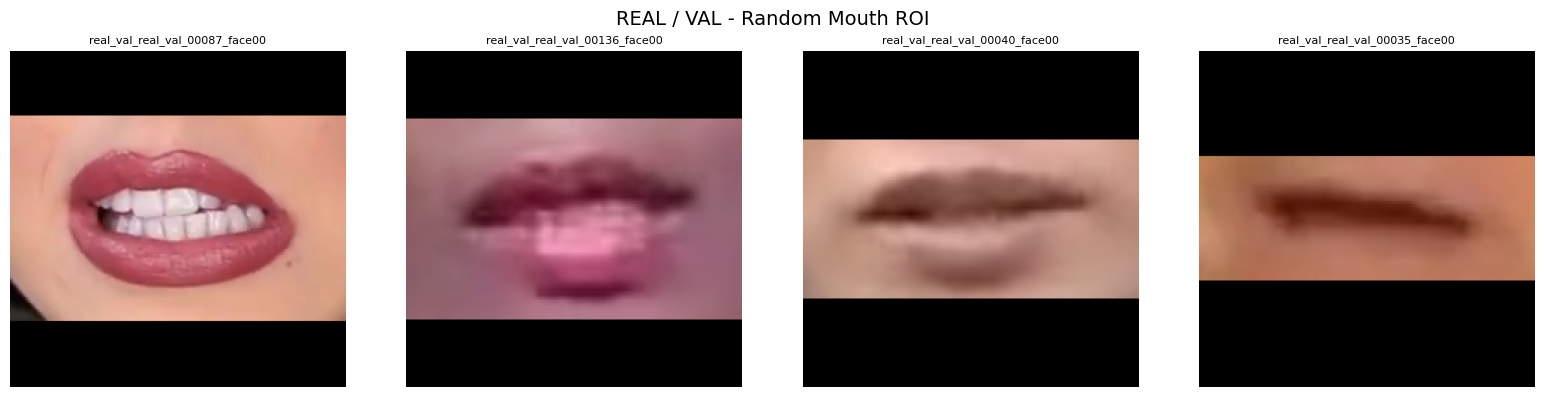

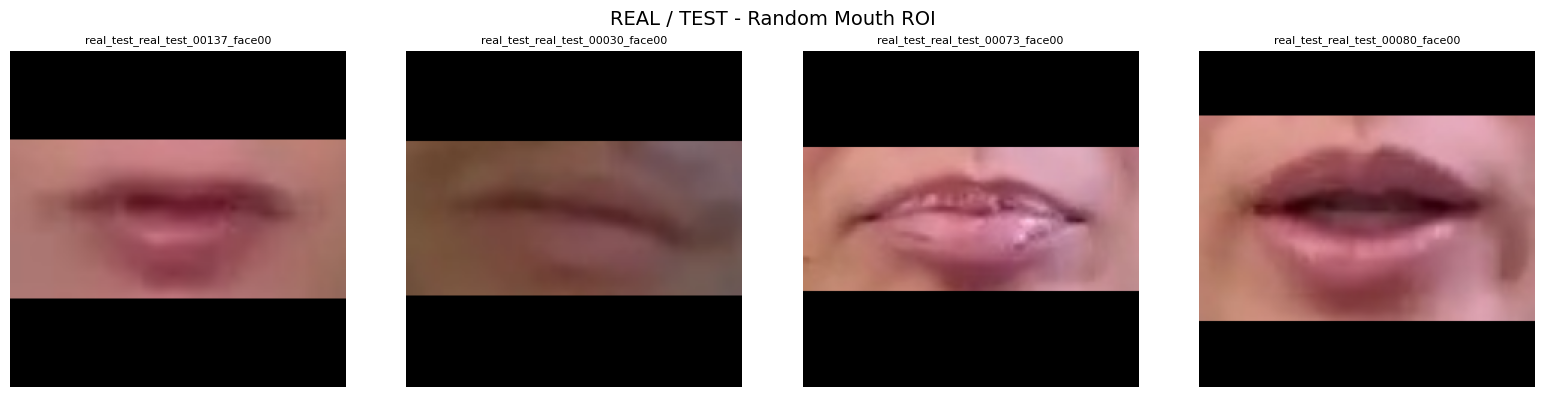


###########################################################################
✓ QUALITY CONTROL BAŞARILI
✓ Eksik çıktı dosyası bulunmadı.
✓ Duplicate sample_id bulunmadı.
###########################################################################

✓ CELL 11 TAMAMLANDI


In [28]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 11 - Final Quality Control
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Tüm Mouth ROI çıktılarını saymak.
# 2) Metadata kayıtlarını kontrol etmek.
# 3) Eksik dosya yollarını tespit etmek.
# 4) SUCCESS / ERROR / SKIPPED dağılımını incelemek.
# 5) Fake ve Real verilerinden rastgele ağız örnekleri göstermek.
# 6) Train / Val / Test dağılımını doğrulamak.
#
# Bu hücre dataset'i DEĞİŞTİRMEZ.
# Yalnızca kalite kontrolü yapar.


import random
import matplotlib.pyplot as plt


print("=" * 75)
print("MOUTH ROI - FINAL QUALITY CONTROL")
print("=" * 75)


# ==========================================================
# 1. GLOBAL METADATA DOSYASINI OKU
# ==========================================================

GLOBAL_METADATA_PATH = (
    OUTPUT_ROOT
    / "metadata.csv"
)


if not GLOBAL_METADATA_PATH.exists():

    raise FileNotFoundError(
        "Global metadata.csv bulunamadı."
    )


global_df = pd.read_csv(
    GLOBAL_METADATA_PATH,
    encoding="utf-8-sig"
)


print(
    f"\nGlobal metadata kayıt sayısı: "
    f"{len(global_df)}"
)


# ==========================================================
# 2. TEMEL METADATA KONTROLÜ
# ==========================================================

print("\n" + "=" * 75)
print("METADATA DURUM DAĞILIMI")
print("=" * 75)


status_counts = (
    global_df[
        "status"
    ]
    .fillna("UNKNOWN")
    .value_counts()
)


print(
    status_counts
)


# ==========================================================
# 3. LABEL DAĞILIMI
# ==========================================================

print("\n" + "=" * 75)
print("LABEL DAĞILIMI")
print("=" * 75)


label_counts = (
    global_df[
        "label"
    ]
    .fillna("UNKNOWN")
    .value_counts()
)


print(
    label_counts
)


# ==========================================================
# 4. SPLIT DAĞILIMI
# ==========================================================

print("\n" + "=" * 75)
print("SPLIT DAĞILIMI")
print("=" * 75)


split_counts = (
    global_df[
        "split"
    ]
    .fillna("UNKNOWN")
    .value_counts()
)


print(
    split_counts
)


# ==========================================================
# 5. LABEL + SPLIT TABLOSU
# ==========================================================

print("\n" + "=" * 75)
print("LABEL / SPLIT DAĞILIMI")
print("=" * 75)


distribution_table = pd.crosstab(
    global_df["label"],
    global_df["split"]
)


display(
    distribution_table
)


# ==========================================================
# 6. SUCCESS KAYITLARINI AYIR
# ==========================================================

success_df = global_df[
    global_df[
        "status"
    ] == "SUCCESS"
].copy()


print(
    f"\nBaşarılı Mouth ROI metadata kaydı: "
    f"{len(success_df)}"
)


# ==========================================================
# 7. ERROR KAYITLARI
# ==========================================================

error_df = global_df[
    global_df[
        "status"
    ] == "ERROR"
].copy()


print(
    f"Hatalı metadata kaydı: "
    f"{len(error_df)}"
)


# ==========================================================
# 8. SKIPPED KAYITLARI
# ==========================================================

skipped_df = global_df[
    global_df[
        "status"
    ] == "SKIPPED"
].copy()


print(
    f"Atlanan metadata kaydı: "
    f"{len(skipped_df)}"
)


# ==========================================================
# 9. HATA TİPLERİNİ GÖSTER
# ==========================================================

if len(error_df) > 0:

    print("\n" + "=" * 75)
    print("EN SIK ERROR TİPLERİ")
    print("=" * 75)


    error_counts = (
        error_df[
            "error"
        ]
        .fillna("UNKNOWN")
        .value_counts()
        .head(20)
    )


    print(
        error_counts
    )


else:

    print(
        "\n✓ ERROR kaydı bulunmuyor."
    )


# ==========================================================
# 10. SKIPPED NEDENLERİ
# ==========================================================

if len(skipped_df) > 0:

    print("\n" + "=" * 75)
    print("SKIPPED NEDENLERİ")
    print("=" * 75)


    skipped_counts = (
        skipped_df[
            "error"
        ]
        .fillna("UNKNOWN")
        .value_counts()
    )


    print(
        skipped_counts
    )


# ==========================================================
# 11. DOSYA VARLIK KONTROLÜ
# ==========================================================
#
# SUCCESS olan her metadata kaydının gerçekten:
#
# - mouth image
# - landmarks JSON
# - debug image
#
# içerip içermediğini kontrol ediyoruz.


missing_mouth_files = []

missing_landmark_files = []

missing_debug_files = []


for _, row in success_df.iterrows():

    # ------------------------------------------------------
    # Mouth ROI
    # ------------------------------------------------------

    mouth_path = row[
        "mouth_path"
    ]


    if (
        pd.isna(mouth_path)
        or
        not Path(
            str(mouth_path)
        ).exists()
    ):

        missing_mouth_files.append(
            row[
                "sample_id"
            ]
        )


    # ------------------------------------------------------
    # Landmark
    # ------------------------------------------------------

    landmark_path = row[
        "landmarks_path"
    ]


    if (
        pd.isna(landmark_path)
        or
        not Path(
            str(landmark_path)
        ).exists()
    ):

        missing_landmark_files.append(
            row[
                "sample_id"
            ]
        )


    # ------------------------------------------------------
    # Debug
    # ------------------------------------------------------

    if SAVE_DEBUG:

        debug_path = row[
            "debug_path"
        ]


        if (
            pd.isna(debug_path)
            or
            not Path(
                str(debug_path)
            ).exists()
        ):

            missing_debug_files.append(
                row[
                    "sample_id"
                ]
            )


print("\n" + "=" * 75)
print("DOSYA VARLIK KONTROLÜ")
print("=" * 75)


print(
    "Eksik Mouth ROI:",
    len(
        missing_mouth_files
    )
)


print(
    "Eksik Landmark JSON:",
    len(
        missing_landmark_files
    )
)


if SAVE_DEBUG:

    print(
        "Eksik Debug:",
        len(
            missing_debug_files
        )
    )


# ==========================================================
# 12. DUPLICATE SAMPLE ID KONTROLÜ
# ==========================================================

duplicate_sample_count = int(
    global_df[
        "sample_id"
    ].duplicated().sum()
)


print("\n" + "=" * 75)
print("SAMPLE ID KONTROLÜ")
print("=" * 75)


print(
    "Duplicate sample_id sayısı:",
    duplicate_sample_count
)


if duplicate_sample_count == 0:

    print(
        "✓ sample_id değerleri benzersiz."
    )

else:

    print(
        "⚠ Duplicate sample_id bulundu."
    )


# ==========================================================
# 13. MOUTH ROI DOSYA SAYILARI
# ==========================================================

print("\n" + "=" * 75)
print("MOUTH ROI DOSYA SAYILARI")
print("=" * 75)


roi_count_rows = []


for label in LABELS:

    for split in SPLITS:

        mouth_folder = (
            OUTPUT_ROOT
            / label
            / split
            / "mouth"
        )


        mouth_files = list(
            mouth_folder.glob(
                "*.png"
            )
        )


        roi_count = len(
            mouth_files
        )


        roi_count_rows.append({

            "label": label,

            "split": split,

            "mouth_roi_files": (
                roi_count
            )
        })


roi_count_df = pd.DataFrame(
    roi_count_rows
)


display(
    roi_count_df
)


# ==========================================================
# 14. RASTGELE ROI ÖRNEKLERİNİ GÖSTER
# ==========================================================

def show_random_mouth_samples(
    label,
    split,
    sample_count=4
):
    """
    Belirli label/split içerisinden rastgele Mouth ROI
    örneklerini gösterir.
    """

    folder = (
        OUTPUT_ROOT
        / label
        / split
        / "mouth"
    )


    files = list(
        folder.glob(
            "*.png"
        )
    )


    if len(files) == 0:

        print(
            f"⚠ {label}/{split} içinde ROI bulunamadı."
        )

        return


    sample_count = min(
        sample_count,
        len(files)
    )


    selected_files = random.sample(
        files,
        sample_count
    )


    fig, axes = plt.subplots(
        1,
        sample_count,
        figsize=(
            4 * sample_count,
            4
        )
    )


    # Tek görüntü durumunda axes liste olmayabilir.
    if sample_count == 1:

        axes = [
            axes
        ]


    for axis, image_path in zip(
        axes,
        selected_files
    ):

        image_bgr = cv2.imread(
            str(
                image_path
            )
        )


        if image_bgr is None:

            axis.set_title(
                "READ ERROR"
            )

            axis.axis(
                "off"
            )

            continue


        image_rgb = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2RGB
        )


        axis.imshow(
            image_rgb
        )


        axis.set_title(
            image_path.stem,
            fontsize=8
        )


        axis.axis(
            "off"
        )


    plt.suptitle(
        f"{label.upper()} / {split.upper()} - Random Mouth ROI",
        fontsize=14
    )


    plt.tight_layout()

    plt.show()


# ==========================================================
# 15. HER BÖLÜMDEN ÖRNEK GÖSTER
# ==========================================================

for label in LABELS:

    for split in SPLITS:

        show_random_mouth_samples(
            label=label,
            split=split,
            sample_count=4
        )


# ==========================================================
# 16. GENEL QC SONUCU
# ==========================================================

qc_passed = (

    len(
        missing_mouth_files
    ) == 0

    and

    len(
        missing_landmark_files
    ) == 0

    and

    (
        not SAVE_DEBUG
        or
        len(
            missing_debug_files
        ) == 0
    )

    and

    duplicate_sample_count == 0
)


print("\n" + "#" * 75)


if qc_passed:

    print(
        "✓ QUALITY CONTROL BAŞARILI"
    )

    print(
        "✓ Eksik çıktı dosyası bulunmadı."
    )

    print(
        "✓ Duplicate sample_id bulunmadı."
    )


else:

    print(
        "⚠ QUALITY CONTROL UYARISI"
    )

    print(
        "Bazı kontroller başarısız. "
        "Yukarıdaki sonuçlar incelenmeli."
    )


print("#" * 75)

print(
    "\n✓ CELL 11 TAMAMLANDI"
)

In [29]:
# ==========================================================
# MOUTH ROI EXTRACTION PROJECT
# Cell 12 - Final Dataset Validation & Report Summary
# ==========================================================

# Bu hücre Mouth ROI veri hazırlama aşamasının SON hücresidir.
#
# Amaç:
#
# 1) 3000 input frame sayısını tekrar doğrulamak.
# 2) Global metadata.csv dosyasını kontrol etmek.
# 3) Fake / Real ve Train / Val / Test sonuçlarını özetlemek.
# 4) SUCCESS / SKIPPED / ERROR sayılarını hesaplamak.
# 5) Mouth ROI, landmark ve debug dosya sayılarını kontrol etmek.
# 6) run_config.json ve processing_summary.json dosyalarını
#    doğrulamak.
# 7) Son proje özetini JSON olarak kaydetmek.
# 8) Raporda kullanılabilecek okunabilir TXT özeti oluşturmak.
#
# ----------------------------------------------------------
# BU HÜCRE:
#
# - Görüntüleri değiştirmez.
# - Yeni ROI üretmez.
# - Metadata'yı değiştirmez.
#
# Yalnızca FINAL VALIDATION gerçekleştirir.
# ==========================================================


print("=" * 80)
print("MOUTH ROI - FINAL DATASET VALIDATION")
print("=" * 80)


# ==========================================================
# 1. TEMEL DOSYA YOLLARI
# ==========================================================

GLOBAL_METADATA_PATH = (
    OUTPUT_ROOT
    / "metadata.csv"
)


RUN_CONFIG_PATH = (
    OUTPUT_ROOT
    / "run_config.json"
)


PROCESSING_SUMMARY_PATH = (
    OUTPUT_ROOT
    / "processing_summary.json"
)


FINAL_REPORT_JSON_PATH = (
    OUTPUT_ROOT
    / "final_validation_report.json"
)


FINAL_REPORT_TXT_PATH = (
    OUTPUT_ROOT
    / "final_validation_report.txt"
)


# ==========================================================
# 2. KRİTİK DOSYALAR VAR MI?
# ==========================================================

print("\n" + "=" * 80)
print("KRİTİK DOSYA KONTROLÜ")
print("=" * 80)


critical_files = {

    "metadata.csv":
        GLOBAL_METADATA_PATH,

    "run_config.json":
        RUN_CONFIG_PATH,

    "processing_summary.json":
        PROCESSING_SUMMARY_PATH
}


critical_file_status = {}


for name, path in critical_files.items():

    exists = path.exists()

    critical_file_status[
        name
    ] = bool(
        exists
    )


    print(
        f"{name:<28}: "
        f"{exists}"
    )


# Global metadata yoksa final validation yapılamaz.
if not GLOBAL_METADATA_PATH.exists():

    raise FileNotFoundError(
        "Global metadata.csv bulunamadı. "
        "Cell 10 ve Cell 11 sonuçlarını kontrol et."
    )


# ==========================================================
# 3. GLOBAL METADATA'YI OKU
# ==========================================================

global_df = pd.read_csv(
    GLOBAL_METADATA_PATH,
    encoding="utf-8-sig"
)


print("\n")
print(
    f"Global metadata satır sayısı: "
    f"{len(global_df)}"
)


# ==========================================================
# 4. INPUT FRAME SAYILARINI TEKRAR HESAPLA
# ==========================================================

print("\n" + "=" * 80)
print("INPUT FRAME SAYILARI")
print("=" * 80)


final_input_counts = {}


total_input_frames_final = 0


for label in LABELS:

    final_input_counts[
        label
    ] = {}


    for split in SPLITS:

        frames = collect_frames(
            label,
            split
        )


        count = len(
            frames
        )


        final_input_counts[
            label
        ][
            split
        ] = int(
            count
        )


        total_input_frames_final += count


        print(
            f"{label:<5} / "
            f"{split:<5} : "
            f"{count}"
        )


print(
    "\nToplam input frame:",
    total_input_frames_final
)


# ==========================================================
# 5. 3000 FRAME DOĞRULAMASI
# ==========================================================

expected_total_frames = 3000


input_count_valid = (
    total_input_frames_final
    == expected_total_frames
)


print("\n3000 frame doğrulaması:")

print(
    f"{total_input_frames_final} / "
    f"{expected_total_frames}"
)


if input_count_valid:

    print(
        "✓ Input dataset frame sayısı doğru."
    )

else:

    print(
        "⚠ Input dataset frame sayısı beklenen değerden farklı."
    )


# ==========================================================
# 6. METADATA STATUS SAYILARI
# ==========================================================

print("\n" + "=" * 80)
print("METADATA STATUS")
print("=" * 80)


status_series = (
    global_df[
        "status"
    ]
    .fillna(
        "UNKNOWN"
    )
    .astype(
        str
    )
)


success_count = int(
    (
        status_series == "SUCCESS"
    ).sum()
)


skipped_count = int(
    (
        status_series == "SKIPPED"
    ).sum()
)


error_count = int(
    (
        status_series == "ERROR"
    ).sum()
)


unknown_count = int(
    ~status_series.isin([
        "SUCCESS",
        "SKIPPED",
        "ERROR"
    ])
    .sum()
)


print(
    f"SUCCESS : {success_count}"
)

print(
    f"SKIPPED : {skipped_count}"
)

print(
    f"ERROR   : {error_count}"
)

print(
    f"UNKNOWN : {unknown_count}"
)


# ==========================================================
# 7. NO FACE SAYISI
# ==========================================================

error_text = (
    global_df[
        "error"
    ]
    .fillna(
        ""
    )
    .astype(
        str
    )
)


no_face_count = int(

    error_text
    .str.contains(
        "NO_FACE_DETECTED",
        regex=False
    )
    .sum()
)


print(
    f"\nNO_FACE_DETECTED : "
    f"{no_face_count}"
)


# ==========================================================
# 8. LABEL / SPLIT METADATA ÖZETİ
# ==========================================================

print("\n" + "=" * 80)
print("LABEL / SPLIT METADATA ÖZETİ")
print("=" * 80)


split_summary_rows = []


for label in LABELS:

    for split in SPLITS:

        subset = global_df[
            (
                global_df[
                    "label"
                ] == label
            )
            &
            (
                global_df[
                    "split"
                ] == split
            )
        ]


        subset_status = (
            subset[
                "status"
            ]
            .fillna("")
            .astype(str)
        )


        subset_success = int(
            (
                subset_status
                == "SUCCESS"
            ).sum()
        )


        subset_skipped = int(
            (
                subset_status
                == "SKIPPED"
            ).sum()
        )


        subset_error = int(
            (
                subset_status
                == "ERROR"
            ).sum()
        )


        split_summary_rows.append({

            "label":
                label,

            "split":
                split,

            "input_frames":
                final_input_counts[
                    label
                ][
                    split
                ],

            "metadata_records":
                int(
                    len(
                        subset
                    )
                ),

            "success":
                subset_success,

            "skipped":
                subset_skipped,

            "error":
                subset_error
        })


split_summary_df = pd.DataFrame(
    split_summary_rows
)


display(
    split_summary_df
)


# ==========================================================
# 9. GERÇEK OUTPUT DOSYA SAYILARI
# ==========================================================

print("\n" + "=" * 80)
print("OUTPUT DOSYA SAYILARI")
print("=" * 80)


output_file_rows = []


total_mouth_files = 0

total_landmark_files = 0

total_debug_files = 0


for label in LABELS:

    for split in SPLITS:

        split_root = (
            OUTPUT_ROOT
            / label
            / split
        )


        mouth_folder = (
            split_root
            / "mouth"
        )


        landmarks_folder = (
            split_root
            / "landmarks"
        )


        debug_folder = (
            split_root
            / "debug"
        )


        mouth_count = len(
            list(
                mouth_folder.glob(
                    "*.png"
                )
            )
        )


        landmark_count = len(
            list(
                landmarks_folder.glob(
                    "*.json"
                )
            )
        )


        debug_count = len(
            list(
                debug_folder.glob(
                    "*.jpg"
                )
            )
        )


        total_mouth_files += (
            mouth_count
        )


        total_landmark_files += (
            landmark_count
        )


        total_debug_files += (
            debug_count
        )


        output_file_rows.append({

            "label":
                label,

            "split":
                split,

            "mouth_files":
                mouth_count,

            "landmark_files":
                landmark_count,

            "debug_files":
                debug_count
        })


output_files_df = pd.DataFrame(
    output_file_rows
)


display(
    output_files_df
)


print(
    f"\nToplam Mouth ROI : "
    f"{total_mouth_files}"
)


print(
    f"Toplam Landmarks : "
    f"{total_landmark_files}"
)


print(
    f"Toplam Debug     : "
    f"{total_debug_files}"
)


# ==========================================================
# 10. SUCCESS - DOSYA SAYISI TUTARLILIĞI
# ==========================================================

mouth_count_matches_success = (
    total_mouth_files
    == success_count
)


landmark_count_matches_success = (
    total_landmark_files
    == success_count
)


if SAVE_DEBUG:

    debug_count_matches_success = (
        total_debug_files
        == success_count
    )

else:

    debug_count_matches_success = True


print("\n" + "=" * 80)
print("SUCCESS / DOSYA TUTARLILIĞI")
print("=" * 80)


print(
    "Mouth ROI == SUCCESS :",
    mouth_count_matches_success
)


print(
    "Landmarks == SUCCESS :",
    landmark_count_matches_success
)


print(
    "Debug == SUCCESS     :",
    debug_count_matches_success
)


# ==========================================================
# 11. DUPLICATE SAMPLE ID
# ==========================================================

duplicate_sample_ids = int(
    global_df[
        "sample_id"
    ]
    .duplicated()
    .sum()
)


print(
    "\nDuplicate sample_id:",
    duplicate_sample_ids
)


# ==========================================================
# 12. SOURCE FRAME TEKRAR KONTROLÜ
# ==========================================================
#
# Bir frame birden fazla yüz içeriyorsa aynı source_frame'in
# birden fazla metadata kaydında bulunması NORMALDİR.
#
# Bu nedenle burada yalnızca kaç benzersiz input frame'in
# metadata içerisinde temsil edildiğini kontrol ediyoruz.


unique_source_frames = int(
    global_df[
        "source_frame"
    ]
    .nunique()
)


print(
    "\nMetadata içerisindeki benzersiz "
    "source frame sayısı:",
    unique_source_frames
)


# ==========================================================
# 13. FRAME COVERAGE
# ==========================================================
#
# İdeal olarak her input frame metadata'da en az bir defa
# temsil edilmelidir.
#
# Yüz bulunamazsa bile SKIPPED kaydı ürettiğimiz için
# 3000 frame'in tamamının metadata içerisinde bulunmasını
# bekliyoruz.


frame_coverage_valid = (
    unique_source_frames
    == total_input_frames_final
)


print(
    "Frame coverage doğru mu? :",
    frame_coverage_valid
)


# ==========================================================
# 14. RUN CONFIG OKU
# ==========================================================

run_config_data = None


if RUN_CONFIG_PATH.exists():

    with open(
        RUN_CONFIG_PATH,
        "r",
        encoding="utf-8"
    ) as file:

        run_config_data = json.load(
            file
        )


# ==========================================================
# 15. PROCESSING SUMMARY OKU
# ==========================================================

processing_summary_data = None


if PROCESSING_SUMMARY_PATH.exists():

    with open(
        PROCESSING_SUMMARY_PATH,
        "r",
        encoding="utf-8"
    ) as file:

        processing_summary_data = (
            json.load(
                file
            )
        )


# ==========================================================
# 16. BAŞARI ORANI
# ==========================================================
#
# Burada dikkat:
#
# Eğer bir frame içerisinde birden fazla yüz varsa SUCCESS
# sayısı 3000'den büyük olabilir.
#
# O nedenle iki oran hesaplıyoruz:
#
# 1) metadata success ratio
# 2) frame coverage ratio


if len(global_df) > 0:

    metadata_success_ratio = (
        success_count
        / len(global_df)
    ) * 100

else:

    metadata_success_ratio = 0.0


if total_input_frames_final > 0:

    frame_coverage_ratio = (
        unique_source_frames
        / total_input_frames_final
    ) * 100

else:

    frame_coverage_ratio = 0.0


print("\n")
print(
    f"Metadata success ratio : "
    f"{metadata_success_ratio:.2f}%"
)


print(
    f"Frame coverage ratio   : "
    f"{frame_coverage_ratio:.2f}%"
)


# ==========================================================
# 17. FINAL VALIDATION KARARI
# ==========================================================

final_validation_passed = (

    input_count_valid

    and

    frame_coverage_valid

    and

    (
        duplicate_sample_ids
        == 0
    )

    and

    mouth_count_matches_success

    and

    landmark_count_matches_success

    and

    debug_count_matches_success

    and

    critical_file_status[
        "metadata.csv"
    ]

    and

    critical_file_status[
        "run_config.json"
    ]
)


print("\n" + "#" * 80)


if final_validation_passed:

    print(
        "✓ FINAL VALIDATION PASSED"
    )

    print(
        "✓ Mouth ROI dataset yapısal olarak hazır."
    )


else:

    print(
        "⚠ FINAL VALIDATION WARNING"
    )

    print(
        "Bazı final kontrolleri başarısız."
    )

    print(
        "Yukarıdaki False / hata sayılarını incele."
    )


print("#" * 80)


# ==========================================================
# 18. FINAL VALIDATION JSON RAPORU
# ==========================================================

final_validation_report = {

    "project":
        "Mouth ROI Extraction",

    "validation_passed":
        bool(
            final_validation_passed
        ),

    "input_dataset": {

        "expected_total_frames":
            int(
                expected_total_frames
            ),

        "actual_total_frames":
            int(
                total_input_frames_final
            ),

        "input_count_valid":
            bool(
                input_count_valid
            ),

        "counts_by_label_split":
            final_input_counts
    },


    "metadata": {

        "total_records":
            int(
                len(
                    global_df
                )
            ),

        "unique_source_frames":
            int(
                unique_source_frames
            ),

        "success":
            int(
                success_count
            ),

        "skipped":
            int(
                skipped_count
            ),

        "error":
            int(
                error_count
            ),

        "unknown":
            int(
                unknown_count
            ),

        "no_face_detected":
            int(
                no_face_count
            ),

        "duplicate_sample_ids":
            int(
                duplicate_sample_ids
            ),

        "metadata_success_ratio_percent":
            round(
                float(
                    metadata_success_ratio
                ),
                3
            ),

        "frame_coverage_ratio_percent":
            round(
                float(
                    frame_coverage_ratio
                ),
                3
            )
    },


    "output_files": {

        "mouth_roi":
            int(
                total_mouth_files
            ),

        "landmarks":
            int(
                total_landmark_files
            ),

        "debug":
            int(
                total_debug_files
            ),

        "mouth_matches_success":
            bool(
                mouth_count_matches_success
            ),

        "landmarks_match_success":
            bool(
                landmark_count_matches_success
            ),

        "debug_matches_success":
            bool(
                debug_count_matches_success
            )
    },


    "configuration": {

        "output_size":
            int(
                OUTPUT_SIZE
            ),

        "mouth_padding_ratio":
            float(
                MOUTH_PADDING_RATIO
            ),

        "mouth_landmark_count":
            int(
                len(
                    MOUTH_LANDMARKS
                )
            ),

        "aspect_ratio_preserved":
            True,

        "save_debug":
            bool(
                SAVE_DEBUG
            )
    },


    "critical_files":
        critical_file_status,


    "validated_at":
        time.strftime(
            "%Y-%m-%d %H:%M:%S"
        )
}


with open(
    FINAL_REPORT_JSON_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_validation_report,
        file,
        ensure_ascii=False,
        indent=4
    )


print(
    "\n✓ final_validation_report.json oluşturuldu."
)


# ==========================================================
# 19. RAPOR İÇİN TXT ÖZETİ
# ==========================================================

report_text = f"""
MOUTH ROI EXTRACTION - FINAL VALIDATION REPORT
============================================================

1. INPUT DATASET
------------------------------------------------------------
Expected frame count : {expected_total_frames}
Detected frame count : {total_input_frames_final}

Fake Train : {final_input_counts['fake']['train']}
Fake Val   : {final_input_counts['fake']['val']}
Fake Test  : {final_input_counts['fake']['test']}

Real Train : {final_input_counts['real']['train']}
Real Val   : {final_input_counts['real']['val']}
Real Test  : {final_input_counts['real']['test']}


2. PROCESSING RESULTS
------------------------------------------------------------
Metadata records     : {len(global_df)}
Unique source frames : {unique_source_frames}

Successful Mouth ROI : {success_count}
Skipped records      : {skipped_count}
Error records        : {error_count}
No-face records      : {no_face_count}

Frame coverage       : {frame_coverage_ratio:.2f}%
Metadata success     : {metadata_success_ratio:.2f}%


3. OUTPUT FILES
------------------------------------------------------------
Mouth ROI images     : {total_mouth_files}
Landmark JSON files  : {total_landmark_files}
Debug images         : {total_debug_files}


4. PREPROCESSING CONFIGURATION
------------------------------------------------------------
Face Landmarker      : MediaPipe Face Landmarker
Mouth landmarks      : {len(MOUTH_LANDMARKS)}
Mouth padding ratio  : {MOUTH_PADDING_RATIO}
Output resolution    : {OUTPUT_SIZE} x {OUTPUT_SIZE}
Aspect ratio         : Preserved
Resize strategy      : Resize + padding


5. DATA ORGANIZATION
------------------------------------------------------------
Classes              : Fake / Real
Splits               : Train / Validation / Test

Fake split           : 80% / 10% / 10%
Real split           : 80% / 10% / 10%


6. VALIDATION
------------------------------------------------------------
Input count valid    : {input_count_valid}
Frame coverage valid : {frame_coverage_valid}
Duplicate sample ID  : {duplicate_sample_ids}

Mouth count valid    : {mouth_count_matches_success}
Landmark count valid : {landmark_count_matches_success}
Debug count valid    : {debug_count_matches_success}

FINAL VALIDATION     : {"PASSED" if final_validation_passed else "WARNING"}

============================================================
"""


with open(
    FINAL_REPORT_TXT_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        report_text
    )


print(
    "✓ final_validation_report.txt oluşturuldu."
)


# ==========================================================
# 20. RAPOR METNİNİ EKRANDA GÖSTER
# ==========================================================

print("\n")
print(
    report_text
)


# ==========================================================
# 21. SON MESAJ
# ==========================================================

print("#" * 80)

print(
    "MOUTH ROI EXTRACTION PIPELINE TAMAMLANDI"
)

print(
    f"Final validation: "
    f"{'PASSED' if final_validation_passed else 'WARNING'}"
)

print("#" * 80)

print(
    "\n✓ CELL 12 TAMAMLANDI"
)

MOUTH ROI - FINAL DATASET VALIDATION

KRİTİK DOSYA KONTROLÜ
metadata.csv                : True
run_config.json             : True
processing_summary.json     : True


Global metadata satır sayısı: 3098

INPUT FRAME SAYILARI
fake  / train : 1200
fake  / val   : 150
fake  / test  : 150
real  / train : 1200
real  / val   : 150
real  / test  : 150

Toplam input frame: 3000

3000 frame doğrulaması:
3000 / 3000
✓ Input dataset frame sayısı doğru.

METADATA STATUS
SUCCESS : 2987
SKIPPED : 111
ERROR   : 0
UNKNOWN : -3099

NO_FACE_DETECTED : 111

LABEL / SPLIT METADATA ÖZETİ


,label,split,input_frames,metadata_records,success,skipped,error
0,fake,train,1200,1254,1192,62,0
1,fake,val,150,154,141,13,0
2,fake,test,150,159,156,3,0
3,real,train,1200,1225,1197,28,0
4,real,val,150,155,155,0,0
5,real,test,150,151,146,5,0



OUTPUT DOSYA SAYILARI


,label,split,mouth_files,landmark_files,debug_files
0,fake,train,1192,1192,1192
1,fake,val,141,141,141
2,fake,test,156,156,156
3,real,train,1197,1197,1197
4,real,val,155,155,155
5,real,test,146,146,146



Toplam Mouth ROI : 2987
Toplam Landmarks : 2987
Toplam Debug     : 2987

SUCCESS / DOSYA TUTARLILIĞI
Mouth ROI == SUCCESS : True
Landmarks == SUCCESS : True
Debug == SUCCESS     : True

Duplicate sample_id: 0

Metadata içerisindeki benzersiz source frame sayısı: 3000
Frame coverage doğru mu? : True


Metadata success ratio : 96.42%
Frame coverage ratio   : 100.00%

################################################################################
✓ FINAL VALIDATION PASSED
✓ Mouth ROI dataset yapısal olarak hazır.
################################################################################

✓ final_validation_report.json oluşturuldu.
✓ final_validation_report.txt oluşturuldu.



MOUTH ROI EXTRACTION - FINAL VALIDATION REPORT

1. INPUT DATASET
------------------------------------------------------------
Expected frame count : 3000
Detected frame count : 3000

Fake Train : 1200
Fake Val   : 150
Fake Test  : 150

Real Train : 1200
Real Val   : 150
Real Test  : 150


2. PROCESSING RESULT